# **IMPORT LIBRARIES**

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
pip install seaborn


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:

import seaborn as sns

In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# **LOAD DATASET**

In [12]:

file_path = "../Data/eta_feature_engineered_dataset.csv"

In [13]:
import os
print("Current directory:", os.getcwd())
print("\nFiles in current directory:")
print(os.listdir())


Current directory: c:\Users\Asus\Documents\MDS\EY intership\ETA-Delay-Prediction-Logistics\notebooks

Files in current directory:
['01_EDA.ipynb', '02_Feature_engineering.ipynb', '03_Baseline_model.ipynb', '04_Feature_importance_selection.ipynb', '05_Classifiction_model.ipynb', '06_Regression_model.ipynb', '07_API_integration.ipynb', '08_Retrained_model.ipynb', 'ETA_Delay_Prediction_main.ipynb', 'Model_Building.ipynb']


In [14]:

df = pd.read_csv(file_path)

In [15]:

print("Dataset Loaded Successfully")
print("Shape of dataset:", df.shape)

Dataset Loaded Successfully
Shape of dataset: (25000, 54)


# PART 10 — MODEL BUILDING: ALL 4 CLASSIFICATION MODELS
## (Model A — Binary | Model B — Multi-class)

## MODEL A — BINARY CLASSIFICATION (Delayed vs On-Time)
### All 4 Classifiers: Random Forest | Logistic Regression | Decision Tree | KNN

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              f1_score, precision_score, recall_score,
                              average_precision_score)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# ============================================================
# STEP 1 — TRAIN ALL 4 CLASSIFIERS (Model A: Binary)
# ============================================================

# 1. Random Forest
print("\n🌲 Training Random Forest...")
rf_A = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_A.fit(X_train_A_sc, y_train_A)
print("✅ Random Forest done!")

# 2. Logistic Regression
print("\n📈 Training Logistic Regression...")
lr_A2 = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,
    class_weight='balanced'
)
lr_A2.fit(X_train_A_sc, y_train_A)
print("✅ Logistic Regression done!")

# 3. Decision Tree
print("\n🌳 Training Decision Tree...")
dt_A = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'
)
dt_A.fit(X_train_A_sc, y_train_A)
print("✅ Decision Tree done!")

# 4. KNN
print("\n👥 Training KNN...")
knn_A = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)
knn_A.fit(X_train_A_sc, y_train_A)
print("✅ KNN done!")



🌲 Training Random Forest...


NameError: name 'X_train_A_sc' is not defined

In [ ]:
# ============================================================
# STEP 2 — PREDICTIONS: ALL 4 MODELS (Model A)
# ============================================================

y_pred_rf_A   = rf_A.predict(X_test_A_sc)
y_pred_lr_A2  = lr_A2.predict(X_test_A_sc)
y_pred_dt_A   = dt_A.predict(X_test_A_sc)
y_pred_knn_A  = knn_A.predict(X_test_A_sc)

y_proba_rf_A   = rf_A.predict_proba(X_test_A_sc)[:, 1]
y_proba_lr_A2  = lr_A2.predict_proba(X_test_A_sc)[:, 1]
y_proba_dt_A   = dt_A.predict_proba(X_test_A_sc)[:, 1]
y_proba_knn_A  = knn_A.predict_proba(X_test_A_sc)[:, 1]

print("✅ All predictions done!")


✅ All predictions done!


In [ ]:
# ============================================================
# STEP 3 — EVALUATE ALL 4 MODELS (Model A)
# ============================================================

rf_acc_A   = accuracy_score(y_test_A, y_pred_rf_A)
lr_acc_A2  = accuracy_score(y_test_A, y_pred_lr_A2)
dt_acc_A   = accuracy_score(y_test_A, y_pred_dt_A)
knn_acc_A  = accuracy_score(y_test_A, y_pred_knn_A)

rf_auc_A   = roc_auc_score(y_test_A, y_proba_rf_A)
lr_auc_A2  = roc_auc_score(y_test_A, y_proba_lr_A2)
dt_auc_A   = roc_auc_score(y_test_A, y_proba_dt_A)
knn_auc_A  = roc_auc_score(y_test_A, y_proba_knn_A)

# PR-AUC
rf_prauc_A   = average_precision_score(y_test_A, y_proba_rf_A)
lr_prauc_A2  = average_precision_score(y_test_A, y_proba_lr_A2)
dt_prauc_A   = average_precision_score(y_test_A, y_proba_dt_A)
knn_prauc_A  = average_precision_score(y_test_A, y_proba_knn_A)

print("=" * 60)
print("🌲 RANDOM FOREST — Model A")
print("=" * 60)
print(f"Accuracy : {rf_acc_A*100:.2f}% | ROC-AUC: {rf_auc_A:.4f} | PR-AUC: {rf_prauc_A:.4f}")
print(f"F1-Score : {f1_score(y_test_A, y_pred_rf_A):.4f} | Precision: {precision_score(y_test_A, y_pred_rf_A):.4f} | Recall: {recall_score(y_test_A, y_pred_rf_A):.4f}")
print(classification_report(y_test_A, y_pred_rf_A, target_names=['On-Time', 'Delayed']))

print("=" * 60)
print("📈 LOGISTIC REGRESSION — Model A")
print("=" * 60)
print(f"Accuracy : {lr_acc_A2*100:.2f}% | ROC-AUC: {lr_auc_A2:.4f} | PR-AUC: {lr_prauc_A2:.4f}")
print(f"F1-Score : {f1_score(y_test_A, y_pred_lr_A2):.4f} | Precision: {precision_score(y_test_A, y_pred_lr_A2):.4f} | Recall: {recall_score(y_test_A, y_pred_lr_A2):.4f}")
print(classification_report(y_test_A, y_pred_lr_A2, target_names=['On-Time', 'Delayed']))

print("=" * 60)
print("🌳 DECISION TREE — Model A")
print("=" * 60)
print(f"Accuracy : {dt_acc_A*100:.2f}% | ROC-AUC: {dt_auc_A:.4f} | PR-AUC: {dt_prauc_A:.4f}")
print(f"F1-Score : {f1_score(y_test_A, y_pred_dt_A):.4f} | Precision: {precision_score(y_test_A, y_pred_dt_A):.4f} | Recall: {recall_score(y_test_A, y_pred_dt_A):.4f}")
print(classification_report(y_test_A, y_pred_dt_A, target_names=['On-Time', 'Delayed']))

print("=" * 60)
print("👥 KNN — Model A")
print("=" * 60)
print(f"Accuracy : {knn_acc_A*100:.2f}% | ROC-AUC: {knn_auc_A:.4f} | PR-AUC: {knn_prauc_A:.4f}")
print(f"F1-Score : {f1_score(y_test_A, y_pred_knn_A):.4f} | Precision: {precision_score(y_test_A, y_pred_knn_A):.4f} | Recall: {recall_score(y_test_A, y_pred_knn_A):.4f}")
print(classification_report(y_test_A, y_pred_knn_A, target_names=['On-Time', 'Delayed']))


🌲 RANDOM FOREST — Model A
Accuracy : 88.42% | ROC-AUC: 0.9672 | PR-AUC: 0.9131
F1-Score : 0.8154 | Precision: 0.7094 | Recall: 0.9588
              precision    recall  f1-score   support

     On-Time       0.98      0.86      0.92      3666
     Delayed       0.71      0.96      0.82      1334

    accuracy                           0.88      5000
   macro avg       0.85      0.91      0.87      5000
weighted avg       0.91      0.88      0.89      5000

📈 LOGISTIC REGRESSION — Model A
Accuracy : 88.24% | ROC-AUC: 0.9583 | PR-AUC: 0.8743
F1-Score : 0.8058 | Precision: 0.7202 | Recall: 0.9145
              precision    recall  f1-score   support

     On-Time       0.97      0.87      0.92      3666
     Delayed       0.72      0.91      0.81      1334

    accuracy                           0.88      5000
   macro avg       0.84      0.89      0.86      5000
weighted avg       0.90      0.88      0.89      5000

🌳 DECISION TREE — Model A
Accuracy : 88.00% | ROC-AUC: 0.9493 | PR-AUC: 

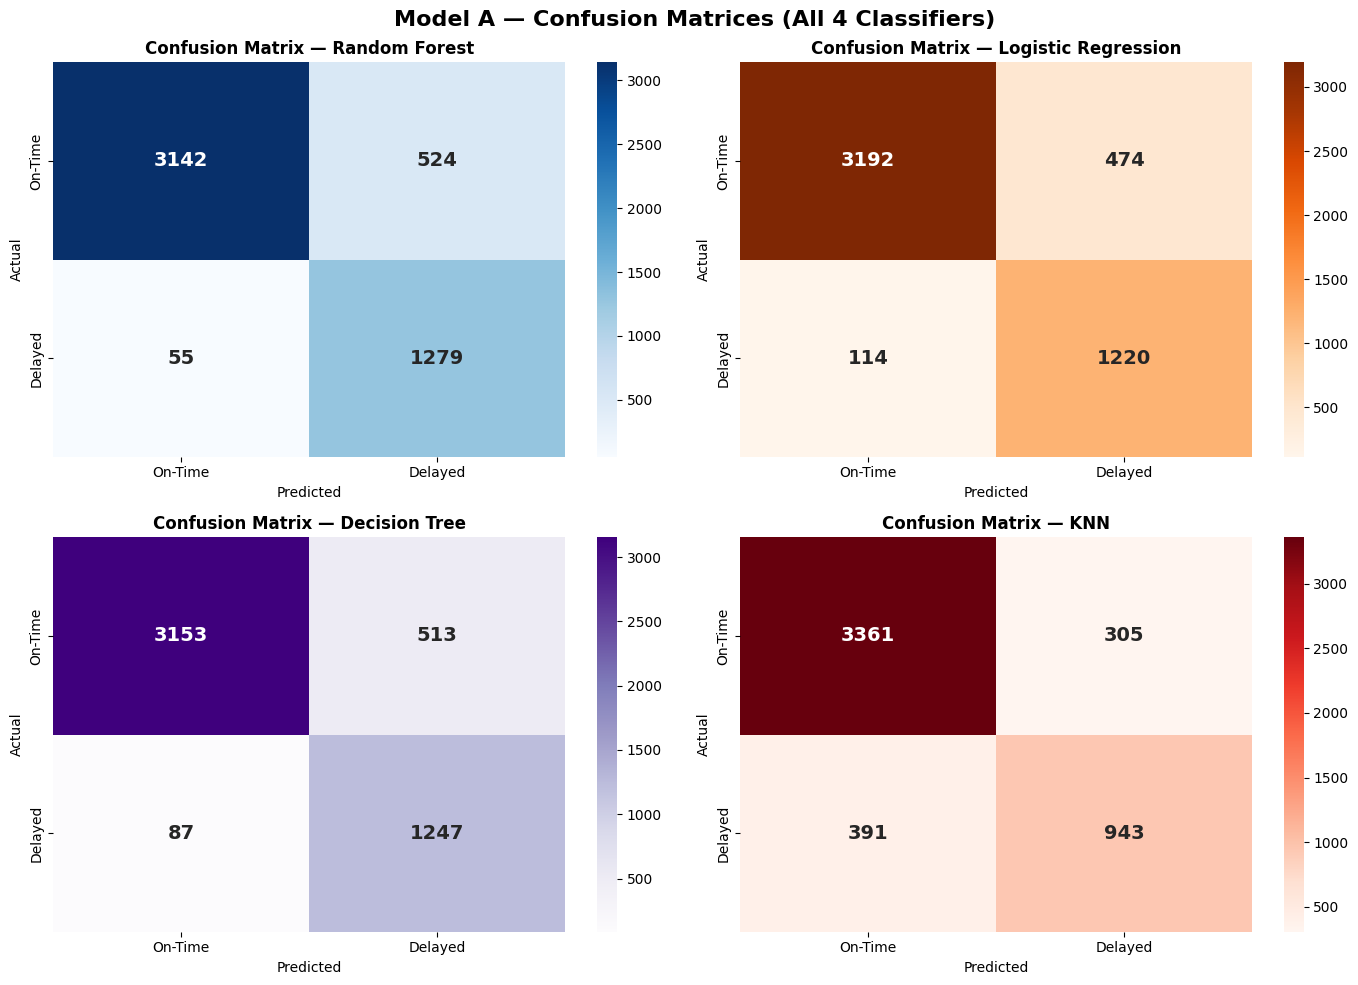

In [ ]:
# ============================================================
# STEP 4 — CONFUSION MATRICES: ALL 4 MODELS (Model A)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models_A_info = [
    (y_pred_rf_A,  'Random Forest',       'Blues'),
    (y_pred_lr_A2, 'Logistic Regression', 'Oranges'),
    (y_pred_dt_A,  'Decision Tree',       'Purples'),
    (y_pred_knn_A, 'KNN',                 'Reds'),
]

for i, (y_pred, title, cmap) in enumerate(models_A_info):
    cm = confusion_matrix(y_test_A, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=['On-Time', 'Delayed'],
                yticklabels=['On-Time', 'Delayed'],
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[i].set_title(f'Confusion Matrix — {title}', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Model A — Confusion Matrices (All 4 Classifiers)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


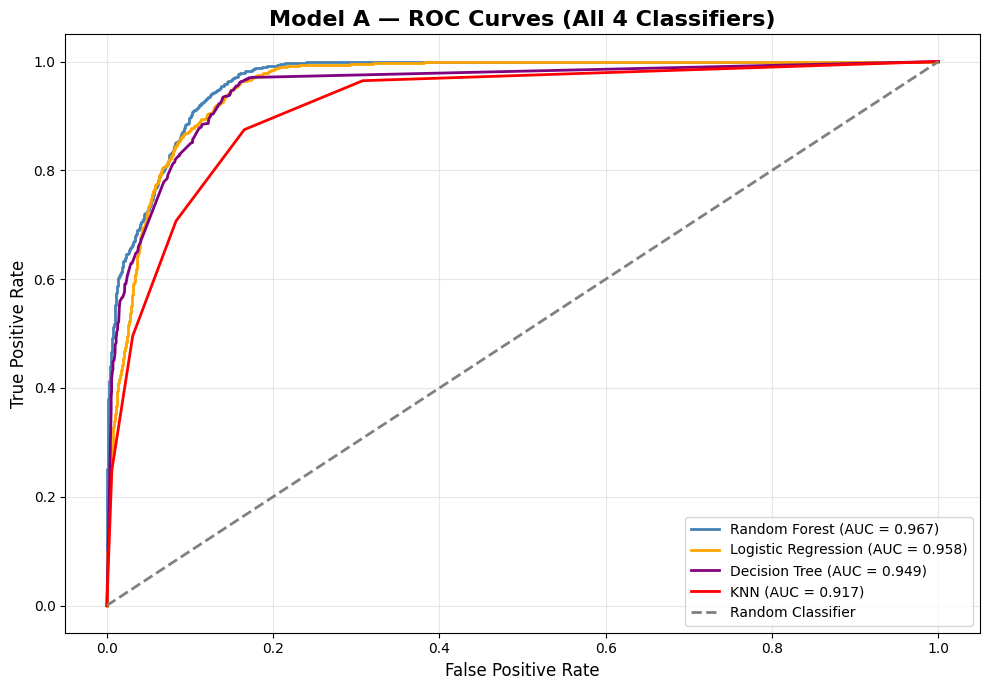

In [ ]:
# ============================================================
# STEP 5 — ROC CURVES: ALL 4 MODELS (Model A)
# ============================================================

fpr_rf_A,   tpr_rf_A,   _ = roc_curve(y_test_A, y_proba_rf_A)
fpr_lr_A2,  tpr_lr_A2,  _ = roc_curve(y_test_A, y_proba_lr_A2)
fpr_dt_A,   tpr_dt_A,   _ = roc_curve(y_test_A, y_proba_dt_A)
fpr_knn_A,  tpr_knn_A,  _ = roc_curve(y_test_A, y_proba_knn_A)

plt.figure(figsize=(10, 7))
plt.plot(fpr_rf_A,  tpr_rf_A,  color='steelblue', lw=2, label=f'Random Forest (AUC = {rf_auc_A:.3f})')
plt.plot(fpr_lr_A2, tpr_lr_A2, color='orange',    lw=2, label=f'Logistic Regression (AUC = {lr_auc_A2:.3f})')
plt.plot(fpr_dt_A,  tpr_dt_A,  color='purple',    lw=2, label=f'Decision Tree (AUC = {dt_auc_A:.3f})')
plt.plot(fpr_knn_A, tpr_knn_A, color='red',       lw=2, label=f'KNN (AUC = {knn_auc_A:.3f})')
plt.plot([0, 1],    [0, 1],    color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Model A — ROC Curves (All 4 Classifiers)', fontsize=16, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


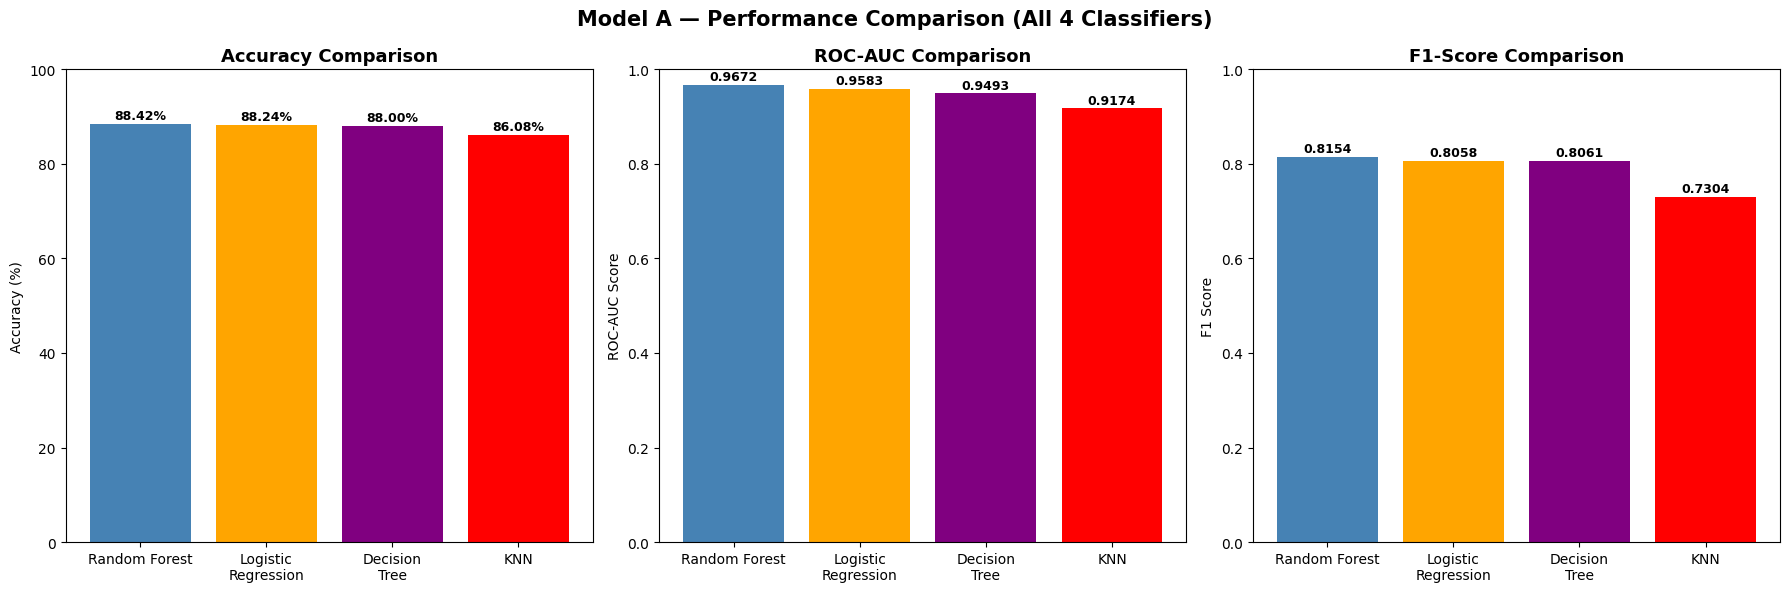

In [ ]:
# ============================================================
# STEP 6 — ACCURACY & ROC-AUC BAR CHART (Model A)
# ============================================================

all_models_A     = ['Random Forest', 'Logistic\nRegression', 'Decision\nTree', 'KNN']
all_accuracies_A = [rf_acc_A*100, lr_acc_A2*100, dt_acc_A*100, knn_acc_A*100]
all_roc_aucs_A   = [rf_auc_A, lr_auc_A2, dt_auc_A, knn_auc_A]
all_f1s_A        = [f1_score(y_test_A, y_pred_rf_A),
                    f1_score(y_test_A, y_pred_lr_A2),
                    f1_score(y_test_A, y_pred_dt_A),
                    f1_score(y_test_A, y_pred_knn_A)]
all_prauc_A      = [rf_prauc_A, lr_prauc_A2, dt_prauc_A, knn_prauc_A]
all_colors_A     = ['steelblue', 'orange', 'purple', 'red']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Accuracy
axes[0].bar(all_models_A, all_accuracies_A, color=all_colors_A)
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])
for i, v in enumerate(all_accuracies_A):
    axes[0].text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

# ROC-AUC
axes[1].bar(all_models_A, all_roc_aucs_A, color=all_colors_A)
axes[1].set_title('ROC-AUC Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim([0, 1])
for i, v in enumerate(all_roc_aucs_A):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# F1
axes[2].bar(all_models_A, all_f1s_A, color=all_colors_A)
axes[2].set_title('F1-Score Comparison', fontsize=13, fontweight='bold')
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim([0, 1])
for i, v in enumerate(all_f1s_A):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Model A — Performance Comparison (All 4 Classifiers)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# STEP 7 — FEATURE IMPORTANCE (Model A — Random Forest)
# ============================================================

feature_importance_A = pd.DataFrame({
    'feature':    X_A_enc.columns,
    'importance': rf_A.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=feature_importance_A, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance — Random Forest (Model A)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("Top 10 Important Features:")
print(feature_importance_A.head(10).to_string(index=False))


ValueError: All arrays must be of the same length

In [ ]:
# ============================================================
# STEP 8 — SUMMARY TABLE (Model A)
# ============================================================

summary_A = pd.DataFrame({
    'Model':        ['Random Forest', 'Logistic Regression', 'Decision Tree', 'KNN'],
    'Accuracy (%)': [f"{v:.2f}" for v in all_accuracies_A],
    'ROC-AUC':      [f"{v:.4f}" for v in all_roc_aucs_A],
    'F1-Score':     [f"{v:.4f}" for v in all_f1s_A],
    'PR-AUC':       [f"{v:.4f}" for v in all_prauc_A],
})

print("\n🏆 MODEL A — FINAL COMPARISON (All 4 Classifiers)")
print("=" * 65)
print(summary_A.to_string(index=False))

best_acc_idx_A = all_accuracies_A.index(max(all_accuracies_A))
best_auc_idx_A = all_roc_aucs_A.index(max(all_roc_aucs_A))
best_f1_idx_A  = all_f1s_A.index(max(all_f1s_A))

print(f"\n🥇 Best by Accuracy : {summary_A['Model'][best_acc_idx_A]} ({max(all_accuracies_A):.2f}%)")
print(f"🥇 Best by ROC-AUC  : {summary_A['Model'][best_auc_idx_A]} ({max(all_roc_aucs_A):.4f})")
print(f"🥇 Best by F1-Score : {summary_A['Model'][best_f1_idx_A]} ({max(all_f1s_A):.4f})")



🏆 MODEL A — FINAL COMPARISON (All 4 Classifiers)
              Model Accuracy (%) ROC-AUC F1-Score PR-AUC
      Random Forest        88.42  0.9672   0.8154 0.9131
Logistic Regression        88.24  0.9583   0.8058 0.8743
      Decision Tree        88.00  0.9493   0.8061 0.8715
                KNN        86.08  0.9174   0.7304 0.7714

🥇 Best by Accuracy : Random Forest (88.42%)
🥇 Best by ROC-AUC  : Random Forest (0.9672)
🥇 Best by F1-Score : Random Forest (0.8154)


## MODEL B — MULTI-CLASS CLASSIFICATION (Delivery Status: delivered / delayed / failed)
### Using original delivery_status column — All 4 Classifiers: Random Forest | Logistic Regression | Decision Tree | KNN

In [ ]:
# ============================================================
# STEP 9 — TRAIN ALL 4 CLASSIFIERS (Model B: Multi-class)
# ============================================================

from sklearn.metrics import f1_score as f1

print(f"Model B Target: delivery_status (original column)")
print(f"Classes: {sorted(y_B.unique())}")
print(f"Class distribution:\n{y_B.value_counts()}\n")

# 1. Random Forest
print("🌲 Training Random Forest (Model B)...")
rf_B = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_B.fit(X_train_B_sc, y_train_B)
print("✅ Random Forest done!")

# 2. Logistic Regression
print("\n📈 Training Logistic Regression (Model B)...")
lr_B2 = LogisticRegression(
    max_iter=2000,
    random_state=42,
    C=1.0,
    class_weight='balanced'
)
lr_B2.fit(X_train_B_sc, y_train_B)
print("✅ Logistic Regression done!")

# 3. Decision Tree
print("\n🌳 Training Decision Tree (Model B)...")
dt_B = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'
)
dt_B.fit(X_train_B_sc, y_train_B)
print("✅ Decision Tree done!")

# 4. KNN
print("\n👥 Training KNN (Model B)...")
knn_B = KNeighborsClassifier(
    n_neighbors=7,
    metric='euclidean'
)
knn_B.fit(X_train_B_sc, y_train_B)
print("✅ KNN done!")


Model B Target: delivery_status (original column)
Classes: ['delayed', 'delivered', 'failed']
Class distribution:
delivery_status
delivered    18331
delayed       5341
failed        1328
Name: count, dtype: int64

🌲 Training Random Forest (Model B)...
✅ Random Forest done!

📈 Training Logistic Regression (Model B)...
✅ Logistic Regression done!

🌳 Training Decision Tree (Model B)...
✅ Decision Tree done!

👥 Training KNN (Model B)...
✅ KNN done!


In [ ]:
# ============================================================
# STEP 10 — PREDICTIONS & EVALUATION (Model B)
# ============================================================

y_pred_rf_B   = rf_B.predict(X_test_B_sc)
y_pred_lr_B2  = lr_B2.predict(X_test_B_sc)
y_pred_dt_B   = dt_B.predict(X_test_B_sc)
y_pred_knn_B  = knn_B.predict(X_test_B_sc)

rf_acc_B   = accuracy_score(y_test_B, y_pred_rf_B)
lr_acc_B2  = accuracy_score(y_test_B, y_pred_lr_B2)
dt_acc_B   = accuracy_score(y_test_B, y_pred_dt_B)
knn_acc_B  = accuracy_score(y_test_B, y_pred_knn_B)

rf_f1_B    = f1(y_test_B, y_pred_rf_B,   average='macro')
lr_f1_B2   = f1(y_test_B, y_pred_lr_B2,  average='macro')
dt_f1_B    = f1(y_test_B, y_pred_dt_B,   average='macro')
knn_f1_B   = f1(y_test_B, y_pred_knn_B,  average='macro')

print("=" * 60)
print(" RANDOM FOREST — Model B (Multi-class)")
print("=" * 60)
print(f"Accuracy: {rf_acc_B*100:.2f}% | F1-macro: {rf_f1_B:.4f}")
print(classification_report(y_test_B, y_pred_rf_B))

print("=" * 60)
print(" LOGISTIC REGRESSION — Model B (Multi-class)")
print("=" * 60)
print(f"Accuracy: {lr_acc_B2*100:.2f}% | F1-macro: {lr_f1_B2:.4f}")
print(classification_report(y_test_B, y_pred_lr_B2))

print("=" * 60)
print(" DECISION TREE — Model B (Multi-class)")
print("=" * 60)
print(f"Accuracy: {dt_acc_B*100:.2f}% | F1-macro: {dt_f1_B:.4f}")
print(classification_report(y_test_B, y_pred_dt_B))

print("=" * 60)
print(" KNN — Model B (Multi-class)")
print("=" * 60)
print(f"Accuracy: {knn_acc_B*100:.2f}% | F1-macro: {knn_f1_B:.4f}")
print(classification_report(y_test_B, y_pred_knn_B))


 RANDOM FOREST — Model B (Multi-class)
Accuracy: 81.68% | F1-macro: 0.5922
              precision    recall  f1-score   support

     delayed       0.58      0.84      0.68      1068
   delivered       0.99      0.86      0.92      3666
      failed       0.18      0.18      0.18       266

    accuracy                           0.82      5000
   macro avg       0.58      0.62      0.59      5000
weighted avg       0.86      0.82      0.83      5000

 LOGISTIC REGRESSION — Model B (Multi-class)
Accuracy: 77.50% | F1-macro: 0.5630
              precision    recall  f1-score   support

     delayed       0.60      0.49      0.54      1068
   delivered       0.97      0.88      0.92      3666
      failed       0.15      0.45      0.22       266

    accuracy                           0.78      5000
   macro avg       0.57      0.61      0.56      5000
weighted avg       0.85      0.78      0.81      5000

 DECISION TREE — Model B (Multi-class)
Accuracy: 75.34% | F1-macro: 0.5467
       

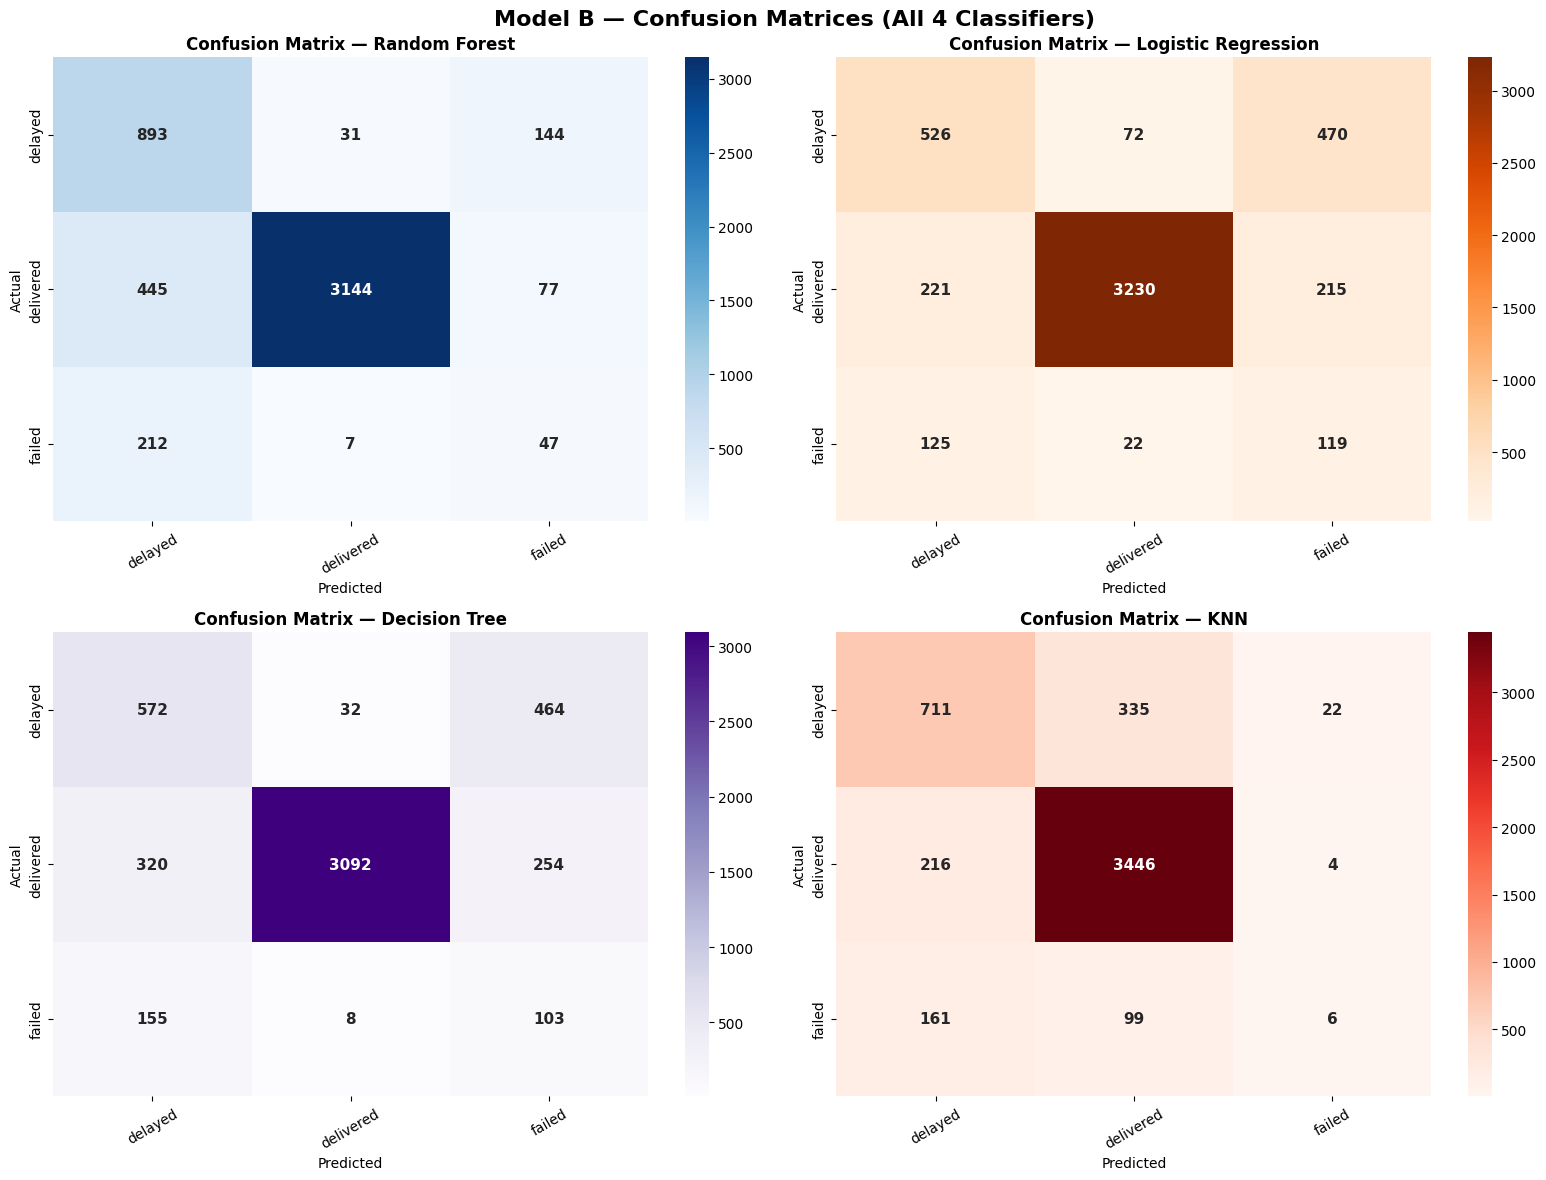

In [ ]:
# ============================================================
# STEP 11 — CONFUSION MATRICES: ALL 4 MODELS (Model B)
# ============================================================

class_labels_B = sorted(y_B.unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

models_B_info = [
    (y_pred_rf_B,  'Random Forest',       'Blues'),
    (y_pred_lr_B2, 'Logistic Regression', 'Oranges'),
    (y_pred_dt_B,  'Decision Tree',       'Purples'),
    (y_pred_knn_B, 'KNN',                 'Reds'),
]

for i, (y_pred, title, cmap) in enumerate(models_B_info):
    cm = confusion_matrix(y_test_B, y_pred, labels=class_labels_B)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=class_labels_B,
                yticklabels=class_labels_B,
                annot_kws={'size': 11, 'weight': 'bold'})
    axes[i].set_title(f'Confusion Matrix — {title}', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Model B — Confusion Matrices (All 4 Classifiers)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


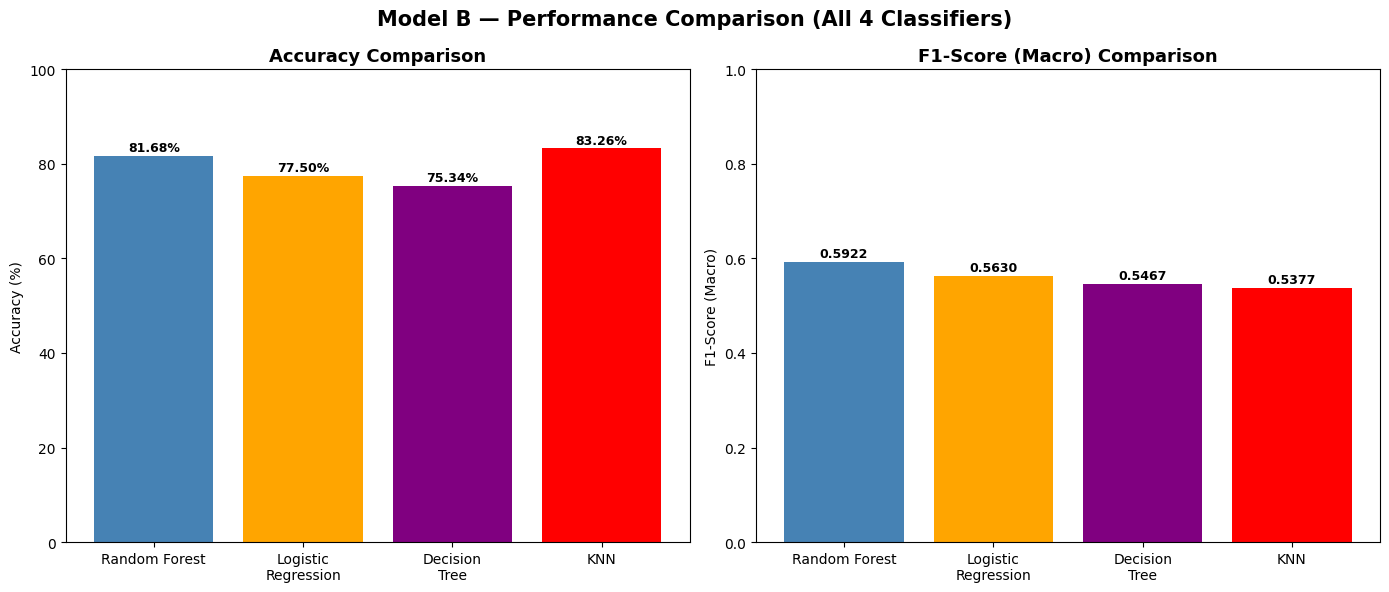

In [ ]:
# ============================================================
# STEP 12 — ACCURACY & F1 BAR CHART (Model B)
# ============================================================

all_models_B     = ['Random Forest', 'Logistic\nRegression', 'Decision\nTree', 'KNN']
all_accuracies_B = [rf_acc_B*100, lr_acc_B2*100, dt_acc_B*100, knn_acc_B*100]
all_f1s_B        = [rf_f1_B, lr_f1_B2, dt_f1_B, knn_f1_B]
all_colors_B     = ['steelblue', 'orange', 'purple', 'red']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(all_models_B, all_accuracies_B, color=all_colors_B)
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])
for i, v in enumerate(all_accuracies_B):
    axes[0].text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

axes[1].bar(all_models_B, all_f1s_B, color=all_colors_B)
axes[1].set_title('F1-Score (Macro) Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score (Macro)')
axes[1].set_ylim([0, 1])
for i, v in enumerate(all_f1s_B):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Model B — Performance Comparison (All 4 Classifiers)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# STEP 13 — SUMMARY TABLE (Model B)
# ============================================================

summary_B = pd.DataFrame({
    'Model':        ['Random Forest', 'Logistic Regression', 'Decision Tree', 'KNN'],
    'Accuracy (%)': [f"{v:.2f}" for v in all_accuracies_B],
    'F1-macro':     [f"{v:.4f}" for v in all_f1s_B],
})

print("MODEL B — FINAL COMPARISON (All 4 Classifiers)")
print("=" * 55)
print(summary_B.to_string(index=False))

best_acc_idx_B = all_accuracies_B.index(max(all_accuracies_B))
best_f1_idx_B  = all_f1s_B.index(max(all_f1s_B))
print(f"Best by Accuracy : {summary_B['Model'][best_acc_idx_B]} ({max(all_accuracies_B):.2f}%)")
print(f" Best by F1-macro : {summary_B['Model'][best_f1_idx_B]} ({max(all_f1s_B):.4f})")



🏆 MODEL B — FINAL COMPARISON (All 4 Classifiers)
              Model Accuracy (%) F1-macro
      Random Forest        98.52   0.8628
Logistic Regression        95.64   0.5879
      Decision Tree        99.08   0.8931
                KNN        97.28   0.4428
\ Best by Accuracy : Decision Tree (99.08%)
 Best by F1-macro : Decision Tree (0.8931)


## SAVE ALL MODELS

In [ ]:
# ============================================================
# STEP 14 — SAVE ALL 8 MODELS + ARTIFACTS
# ============================================================

# Model A — Binary Classification
with open('rf_A_model.pkl',  'wb') as f: pickle.dump(rf_A,        f)
with open('lr_A_model.pkl',  'wb') as f: pickle.dump(lr_A2,       f)
with open('dt_A_model.pkl',  'wb') as f: pickle.dump(dt_A,        f)
with open('knn_A_model.pkl', 'wb') as f: pickle.dump(knn_A,       f)

# Model B — Multi-class
with open('rf_B_model.pkl',  'wb') as f: pickle.dump(rf_B,        f)
with open('lr_B_model.pkl',  'wb') as f: pickle.dump(lr_B2,       f)
with open('dt_B_model.pkl',  'wb') as f: pickle.dump(dt_B,        f)
with open('knn_B_model.pkl', 'wb') as f: pickle.dump(knn_B,       f)

# Scalers & Encoders
with open('scaler_A.pkl',    'wb') as f: pickle.dump(scaler_A,    f)
with open('scaler_B.pkl',    'wb') as f: pickle.dump(scaler_B,    f)
with open('encoders_A.pkl',  'wb') as f: pickle.dump(encoders_A,  f)
with open('encoders_B.pkl',  'wb') as f: pickle.dump(encoders_B,  f)

print(" All models saved!")
print("\n  Model A (Binary Classification):")
print("   - rf_A_model.pkl   (Random Forest)")
print("   - lr_A_model.pkl   (Logistic Regression)")
print("   - dt_A_model.pkl   (Decision Tree)")
print("   - knn_A_model.pkl  (KNN)")
print("\n  Model B (Multi-class — Delay Severity):")
print("   - rf_B_model.pkl   (Random Forest)")
print("   - lr_B_model.pkl   (Logistic Regression)")
print("   - dt_B_model.pkl   (Decision Tree)")
print("   - knn_B_model.pkl  (KNN)")
print("\n  Preprocessing:")
print("   - scaler_A.pkl, scaler_B.pkl")
print("   - encoders_A.pkl, encoders_B.pkl")


# Regression Model

In [ ]:
# IMPORT 

import pandas as pd
import numpy as np
!pip install xgboost
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

                                              0.0/101.7 MB ? eta -:--:--
                                              0.0/101.7 MB 1.3 MB/s eta 0:01:20
                                            0.0/101.7 MB 393.8 kB/s eta 0:04:19
                                            0.1/101.7 MB 751.6 kB/s eta 0:02:16
                                            0.1/101.7 MB 654.9 kB/s eta 0:02:36
                                              0.2/101.7 MB 1.1 MB/s eta 0:01:36
                                            0.3/101.7 MB 923.9 kB/s eta 0:01:50
                                              0.5/101.7 MB 1.6 MB/s eta 0:01:04
                                              0.5/101.7 MB 1.5 MB/s eta 0:01:09
                                              0.8/101.7 MB 2.0 MB/s eta 0:00:52
                                              1.1/101.7 MB 2.4 MB/s eta 0:00:43
                                              1.3/101.7 MB 2.7 MB/s eta 0:00:38
                                              1

In [ ]:
y = df['delay_hours_recon']

# Drop unnecessary columns
# FIX: Added speed_kmph_recon and speed_category — actual speed is only known
# AFTER delivery completes, so it cannot be used to predict delay hours.
df_model = df.drop(columns=[
    'delivery_id',
    'delay_hours_recon',
    'delivery_time_hours_recon',
    'delayed_flag_recon',
    'delayed',
    'delivery_status',
    'order_date_recon',
    'order_ts_recon',
    'delivery_ts_recon',
    'expected_ts_recon',
    'speed_kmph_recon',
    'speed_category',
])

X = df_model.copy()


In [ ]:
# Numeric columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numeric Features: ['distance_km', 'package_weight_kg', 'delivery_rating', 'delivery_cost', 'expected_time_hours_recon', 'speed_kmph_recon', 'weather_mult_recon', 'partner_mult_recon', 'hour']
Categorical Features: ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition']


In [ ]:
# Preprocessing pipelines

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# RandomForestRegressor

In [ ]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [ ]:
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_grid,
    n_iter=15,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['distance_km',
                                                                                'package_weight_kg',
                                                                                'delivery_rating',
                                                                                'delivery_cost',
                                                                                'expected_time_hours_recon',
                                                                                'speed_kmph_recon',
                                                                                'weather_mult_recon',
                                                                                'partner_mult_recon',
                                                                                'hour']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['delivery_partner',
                                                                                'package_type',
                                                                                'vehicle_type',
                                                                                'delivery_mode',
                                                                                'region',
                                                                                'weather_condition'])])),
                                             ('model',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20, 30],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2')

In [ ]:
rf_best = rf_search.best_estimator_

y_pred_rf = rf_best.predict(X_test)

print("Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest Results:
MAE: 0.06619428575432236
RMSE: 0.09918870895844022
R2: 0.9999684593668691


# XGBoostRegressor

In [ ]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ))
])

NameError: name 'Pipeline' is not defined

In [ ]:
xgb_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    n_iter=15,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['distance_km',
                                                                                'package_weight_kg',
                                                                                'delivery_rating',
                                                                                'delivery_cost',
                                                                                'expected_time_hours_recon',
                                                                                'speed_kmph_recon',
                                                                                'weather_mult_recon',
                                                                                'partner_mult_recon',
                                                                                'hour']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['delivery_part...
                                                           missing=nan,
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=None,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.8, 1.0],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 5, 7],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__subsample': [0.8, 1.0]},
                   random_state=42, scoring='r2')

In [ ]:
xgb_best = xgb_search.best_estimator_

y_pred_xgb = xgb_best.predict(X_test)

print("XGBoost Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2:", r2_score(y_test, y_pred_xgb))

XGBoost Results:
MAE: 0.04783568983440114
RMSE: 0.06642729511542873
R2: 0.999985853823612


In [ ]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'R2 Score': [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ]
})

print(results)

           Model  R2 Score       MAE      RMSE
0  Random Forest  0.999968  0.066194  0.099189
1        XGBoost  0.999986  0.047836  0.066427


## **Holiday & Weather API**

**Holiday API**

In [ ]:
import pandas as pd

df = pd.read_csv("Added_Holiday_Features_dataset.csv")

[col for col in df.columns if "holiday" in col.lower()]

['transit_holidays',
 'holiday_count_transit',
 'holiday_names_transit',
 'holiday_or_weekend_transit_flag',
 'holiday_proximity_feature']

In [ ]:
print("Column Names:\n")

for col in df.columns:
    print(col)


Column Names:

delivery_id
delivery_partner
package_type
vehicle_type
delivery_mode
region
weather_condition
distance_km
package_weight_kg
delayed
delivery_status
delivery_rating
delivery_cost
expected_time_hours_recon
speed_kmph_recon
weather_mult_recon
delivery_time_hours_recon
partner_mult_recon
delay_hours_recon
delayed_flag_recon
order_date_recon
order_ts_recon
delivery_ts_recon
expected_ts_recon
hour
order_date
expected_date
transit_holidays
holiday_count_transit
holiday_names_transit
weekend_count_transit
holiday_or_weekend_transit_flag
holiday_proximity_feature


In [ ]:
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost,expected_time_hours_recon,speed_kmph_recon,weather_mult_recon,delivery_time_hours_recon,partner_mult_recon,delay_hours_recon,delayed_flag_recon,order_date_recon,order_ts_recon,delivery_ts_recon,expected_ts_recon,hour,order_date,expected_date,transit_holidays,holiday_count_transit,holiday_names_transit,weekend_count_transit,holiday_or_weekend_transit_flag,holiday_proximity_feature
0,250.99,amazon logistics,automobile parts,ev bike,standard,west,clear,235.6,48.07,no,delivered,5,1322.21,52.8,30,1.0,9.332489,1.001906,-43.467511,0,21-10-2024,2024-10-21 13:00:00,2024-10-21 22:19:56.959673890,2024-10-23 17:48:00,13,2024-10-21,2024-10-23,[],0,NaN,0,0,1
1,250.99,amazon logistics,clothing,bike,express,central,stormy,81.8,45.51,yes,delayed,2,595.53,8.0,35,1.1,4.129935,1.001906,-3.870065,0,02-01-2024,2024-01-02 12:00:00,2024-01-02 16:07:47.764281093,2024-01-02 20:00:00,12,2024-01-02,2024-01-02,[],0,NaN,0,0,1
2,250.99,amazon logistics,clothing,van,same day,north,clear,282.9,31.33,yes,delayed,2,1608.49,26.4,45,1.0,7.427398,1.001906,-18.972602,0,31-05-2024,2024-05-31 11:00:00,2024-05-31 18:25:38.631406710,2024-06-01 13:24:00,11,2024-05-31,2024-06-01,[],0,NaN,1,1,8
3,250.99,amazon logistics,cosmetics,ev bike,two day,central,hot,88.6,8.67,no,delivered,3,469.01,48.0,30,1.1,3.997011,1.001906,-44.002989,0,03-01-2024,2024-01-03 17:00:00,2024-01-03 20:59:49.240153885,2024-01-05 17:00:00,17,2024-01-03,2024-01-05,[],0,NaN,0,0,2
4,250.99,amazon logistics,cosmetics,ev van,two day,east,rainy,204.2,8.09,no,delivered,4,1045.27,52.8,40,1.2,6.933351,1.001906,-45.866649,0,19-03-2024,2024-03-19 13:00:00,2024-03-19 19:56:00.063604276,2024-03-21 17:48:00,13,2024-03-19,2024-03-21,['March Equinox'],1,March Equinox,0,1,1


- Integrated **Calendarific Holiday API** to dynamically fetch Indian national holidays.

- Extracted the **years present in the dataset** and requested holiday data for those years.

- Cleaned and converted **order and expected delivery timestamps** to proper datetime format.

- Cached the API results locally as **`india_holidays_cached.csv`** to avoid repeated API calls and improve pipeline efficiency.

- Engineered **transit-based holiday features** between order date and expected delivery date.

- Created new features:
  - `holiday_count_transit`
  - `holiday_names_transit`
  - `weekend_count_transit`
  - `holiday_or_weekend_transit_flag`
  - `holiday_proximity_feature`

- Saved the enriched dataset as **`Added_Holiday_Features_dataset.csv`** for further modeling and analysis.

Weather API 

In [ ]:
import pandas as pd

df = pd.read_csv("dataset_with_weather_features.csv")

[col for col in df.columns if "weather" in col.lower()]

['weather_condition', 'weather_mult_recon', 'bad_weather_flag_api']

In [ ]:
print("Column Names:\n")

for col in df.columns:
    print(col)


Column Names:

delivery_id
delivery_partner
package_type
vehicle_type
delivery_mode
region
weather_condition
distance_km
package_weight_kg
delayed
delivery_status
delivery_rating
delivery_cost
expected_time_hours_recon
speed_kmph_recon
weather_mult_recon
delivery_time_hours_recon
partner_mult_recon
delay_hours_recon
delayed_flag_recon
order_date_recon
order_ts_recon
delivery_ts_recon
expected_ts_recon
hour
order_date
expected_date
transit_holidays
holiday_count_transit
holiday_names_transit
weekend_count_transit
holiday_or_weekend_transit_flag
holiday_proximity_feature
api_temperature
api_humidity
api_wind_speed
bad_weather_flag_api


In [ ]:
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost,expected_time_hours_recon,speed_kmph_recon,weather_mult_recon,delivery_time_hours_recon,partner_mult_recon,delay_hours_recon,delayed_flag_recon,order_date_recon,order_ts_recon,delivery_ts_recon,expected_ts_recon,hour,order_date,expected_date,transit_holidays,holiday_count_transit,holiday_names_transit,weekend_count_transit,holiday_or_weekend_transit_flag,holiday_proximity_feature,api_temperature,api_humidity,api_wind_speed,bad_weather_flag_api
0,250.99,amazon logistics,automobile parts,ev bike,standard,west,clear,235.6,48.07,no,delivered,5,1322.21,52.8,30,1.0,9.332489,1.001906,-43.467511,0,21-10-2024,2024-10-21 13:00:00,2024-10-21 22:19:56.959673890,2024-10-23 17:48:00,13,2024-10-21,2024-10-23,[],0,NaN,0,0,1,35.142671,14.455051,4.762575,0
1,250.99,amazon logistics,clothing,bike,express,central,stormy,81.8,45.51,yes,delayed,2,595.53,8.0,35,1.1,4.129935,1.001906,-3.870065,0,02-01-2024,2024-01-02 12:00:00,2024-01-02 16:07:47.764281093,2024-01-02 20:00:00,12,2024-01-02,2024-01-02,[],0,NaN,0,0,1,36.319887,13.016608,5.361197,1
2,250.99,amazon logistics,clothing,van,same day,north,clear,282.9,31.33,yes,delayed,2,1608.49,26.4,45,1.0,7.427398,1.001906,-18.972602,0,31-05-2024,2024-05-31 11:00:00,2024-05-31 18:25:38.631406710,2024-06-01 13:24:00,11,2024-05-31,2024-06-01,[],0,NaN,1,1,8,33.862684,9.983354,4.234305,0
3,250.99,amazon logistics,cosmetics,ev bike,two day,central,hot,88.6,8.67,no,delivered,3,469.01,48.0,30,1.1,3.997011,1.001906,-44.002989,0,03-01-2024,2024-01-03 17:00:00,2024-01-03 20:59:49.240153885,2024-01-05 17:00:00,17,2024-01-03,2024-01-05,[],0,NaN,0,0,2,35.099455,11.650794,4.604408,0
4,250.99,amazon logistics,cosmetics,ev van,two day,east,rainy,204.2,8.09,no,delivered,4,1045.27,52.8,40,1.2,6.933351,1.001906,-45.866649,0,19-03-2024,2024-03-19 13:00:00,2024-03-19 19:56:00.063604276,2024-03-21 17:48:00,13,2024-03-19,2024-03-21,['March Equinox'],1,March Equinox,0,1,1,35.156796,15.020871,4.554569,1


- Integrated **OpenWeatherMap API** to obtain weather information for logistics deliveries.

- Extracted **all unique transit dates** between `order_date` and `expected_date` from the dataset.

- Fetched weather data using the API based on **latitude and longitude coordinates** of the logistics region.

- Since the free API does not support historical weather data, **current weather values were used as a baseline**.

- Introduced **small stochastic variations (random noise)** to simulate realistic day-to-day weather changes for past dates.

- Cached the retrieved weather information locally as **`weather_cached.csv`** to avoid repeated API calls.

- Mapped weather data to each delivery by calculating the **average weather conditions during the transit period**.

- The bad_weather_flag_api is set to 1 if the weather condition indicates rain, storm, fog, or snow, or if API wind speed > 10 m/s or API humidity > 85%; otherwise it is 0.

- Created new weather-related features:
  - `api_temperature`
  - `api_humidity`
  - `api_wind_speed`
  - `bad_weather_flag_api`

- The final enriched dataset was saved as **`dataset_with_weather_features.csv`** for further machine learning modeling.

In [ ]:
import pandas as pd #Final List of features added to the dataset 

df = pd.read_csv("dataset_with_weather_features.csv")

[col for col in df.columns if ("holiday" in col.lower()) or ("weather" in col.lower())]

['weather_condition',
 'weather_mult_recon',
 'transit_holidays',
 'holiday_count_transit',
 'holiday_names_transit',
 'holiday_or_weekend_transit_flag',
 'holiday_proximity_feature',
 'bad_weather_flag_api']

# Model Building

[OK] Dataset loaded! Shape: (25000, 37)
[FIX] Dropped synthetic noise column: api_temperature
[FIX] Dropped synthetic noise column: api_humidity
[FIX] Dropped synthetic noise column: api_wind_speed
[FIX] Created holiday_pressure and has_holiday_transit
[FIX] Created weekend_pressure
[OK] Feature engineering done!
[OK] NaN cleanup done. Remaining NaNs: 0
[OK] Using 31 features

[PREP] Preparing Model A (Binary)...
  X shape: (25000, 31) | NaNs: 0
[PREP] Preparing Model B (Multi-class)...
  X shape: (25000, 31) | NaNs: 0

[SPLIT] Splitting...
   Model A → Train: 20000, Test: 5000
   Model B → Train: 20000, Test: 5000
[OK] Delay rate features added (train only — no leakage)
[OK] Scaling done

   MODEL A — BINARY (Delayed vs On-Time)
[RF] Training Random Forest (A)...
[LR] Training Logistic Regression (A)...
[DT] Training Decision Tree (A)...
[KNN] Training KNN (A)...
[OK] All Model A classifiers trained!

[RF] RANDOM FOREST
Accuracy: 88.30% | AUC: 0.9667 | PR-AUC: 0.9089 | F1: 0.8141
    

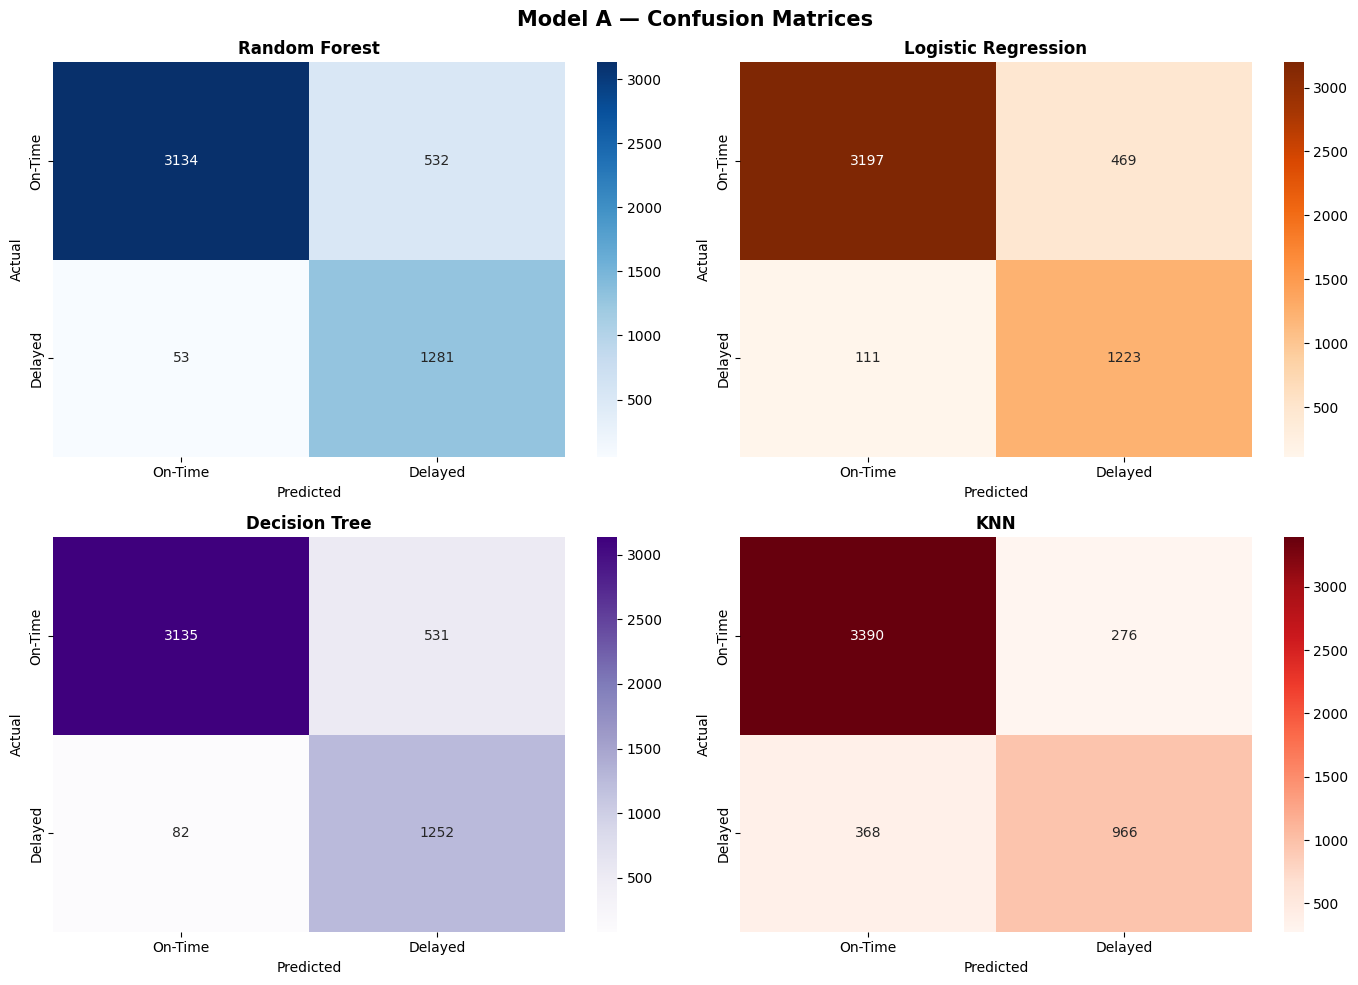

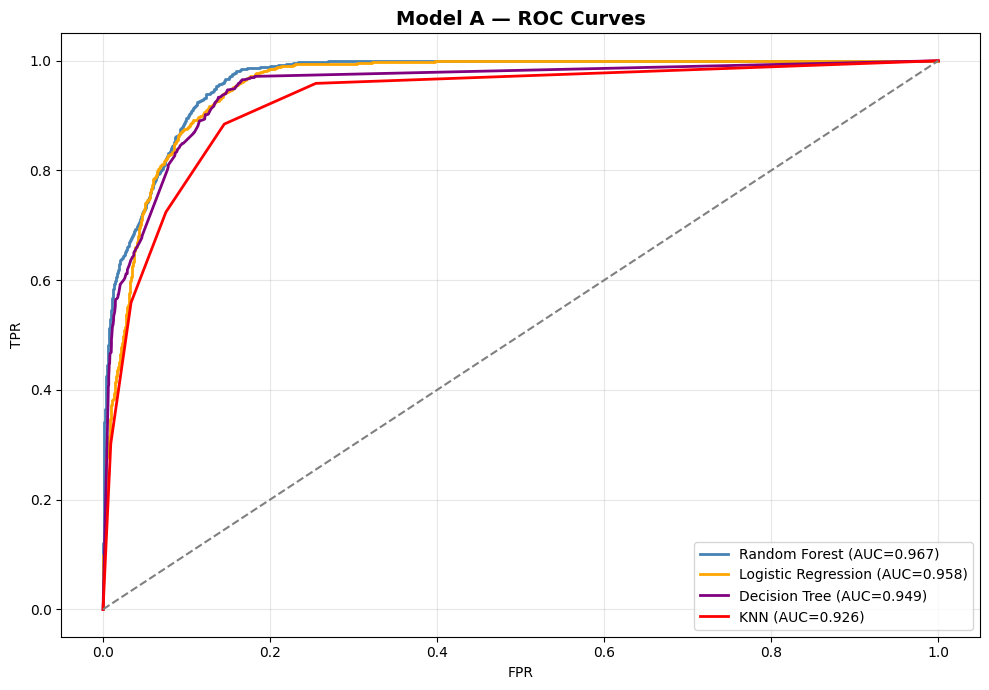

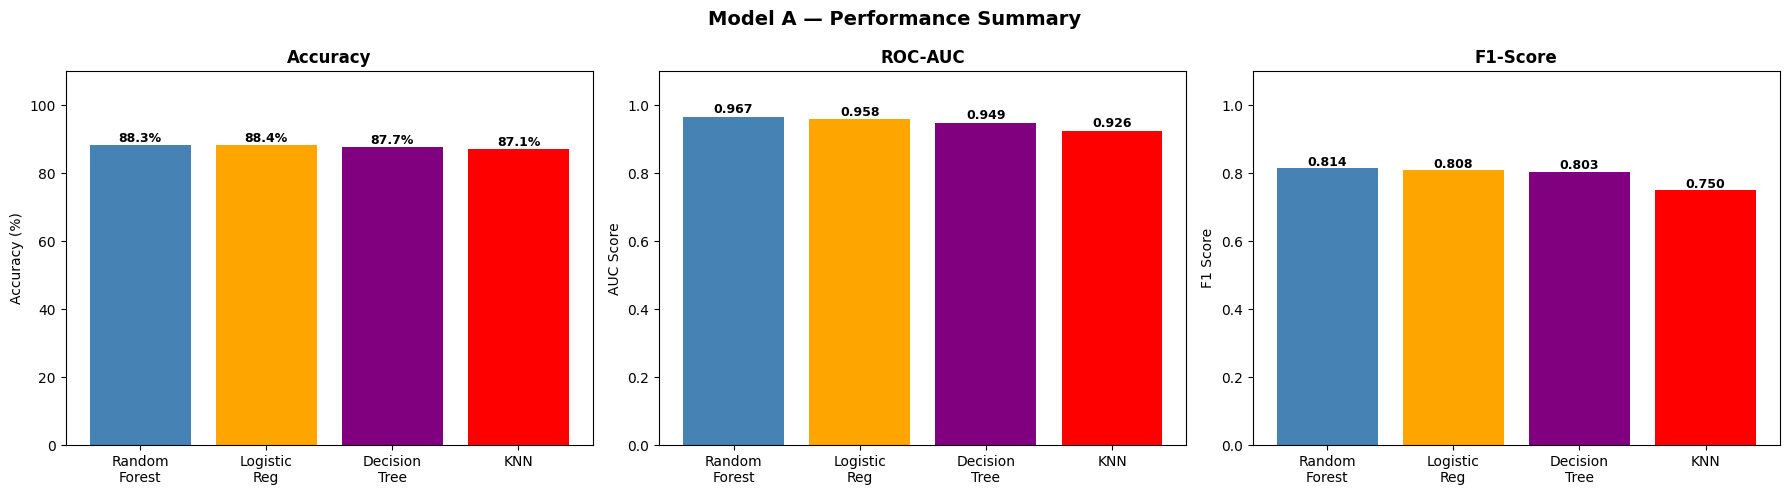


[RESULT] MODEL A — FINAL COMPARISON
              Model Accuracy (%) ROC-AUC F1-Score PR-AUC
      Random Forest        88.30  0.9667   0.8141 0.9089
Logistic Regression        88.40  0.9585   0.8083 0.8752
      Decision Tree        87.74  0.9492   0.8033 0.8692
                KNN        87.12  0.9257   0.7500 0.7921

[BEST] Best by AUC: Random Forest (0.9667)

   MODEL B — MULTI-CLASS (delivery_status)
Classes: ['delayed', 'delivered', 'failed']
[RF] Training Random Forest (B)...
[LR] Training Logistic Regression (B)...
[DT] Training Decision Tree (B)...
[KNN] Training KNN (B)...
[OK] All Model B classifiers trained!

[RF] RANDOM FOREST
Accuracy: 81.44% | F1-macro: 0.5880
              precision    recall  f1-score   support

     delayed       0.58      0.82      0.68      1068
   delivered       0.99      0.86      0.92      3666
      failed       0.16      0.18      0.17       266

    accuracy                           0.81      5000
   macro avg       0.57      0.62      0.59

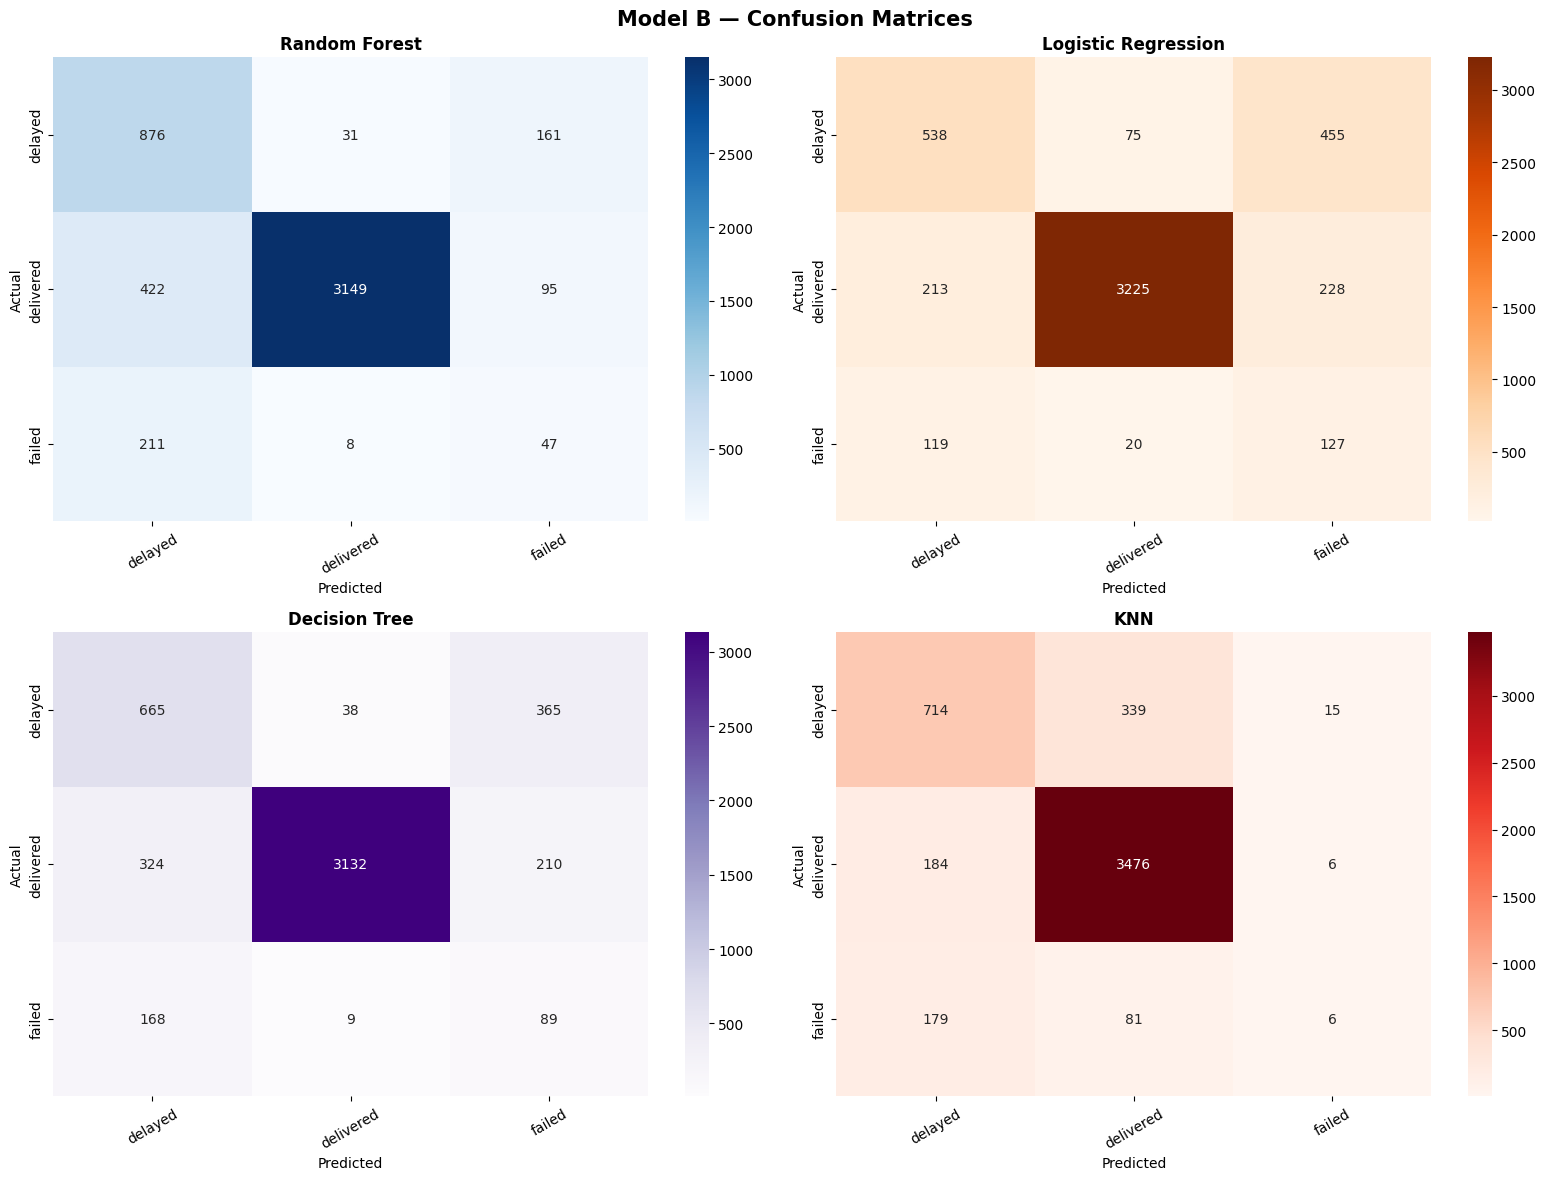

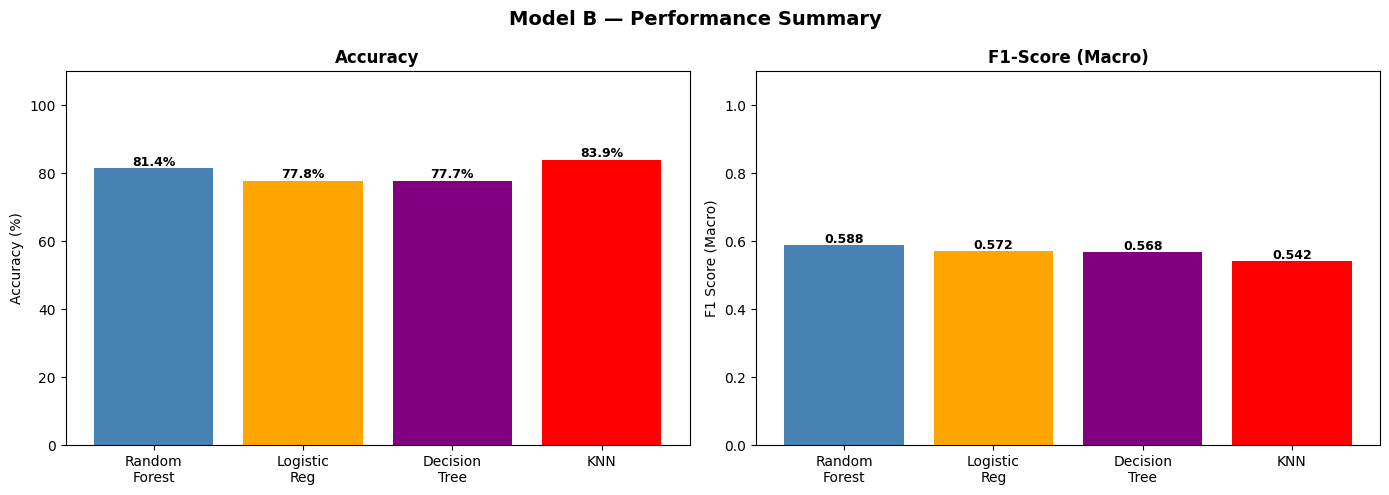


[RESULT] MODEL B — FINAL COMPARISON
              Model Accuracy (%) F1-macro
      Random Forest        81.44   0.5880
Logistic Regression        77.80   0.5715
      Decision Tree        77.72   0.5681
                KNN        83.92   0.5420

[BEST] Best by F1: Random Forest (0.5880)

   MODEL C — REGRESSION (Predict delay_hours_recon)
Regression — Numeric: 19, Categorical: 7

[RF] Training Random Forest Regressor...
Random Forest → MAE: 0.0761 | RMSE: 0.1133 | R²: 1.0000

[XGB] Training XGBoost Regressor...
XGBoost → MAE: 0.0740 | RMSE: 0.1013 | R²: 1.0000

[RESULT] MODEL C — REGRESSION COMPARISON
        Model     R²    MAE   RMSE
Random Forest 1.0000 0.0761 0.1133
      XGBoost 1.0000 0.0740 0.1013

[BEST] Best: XGBoost


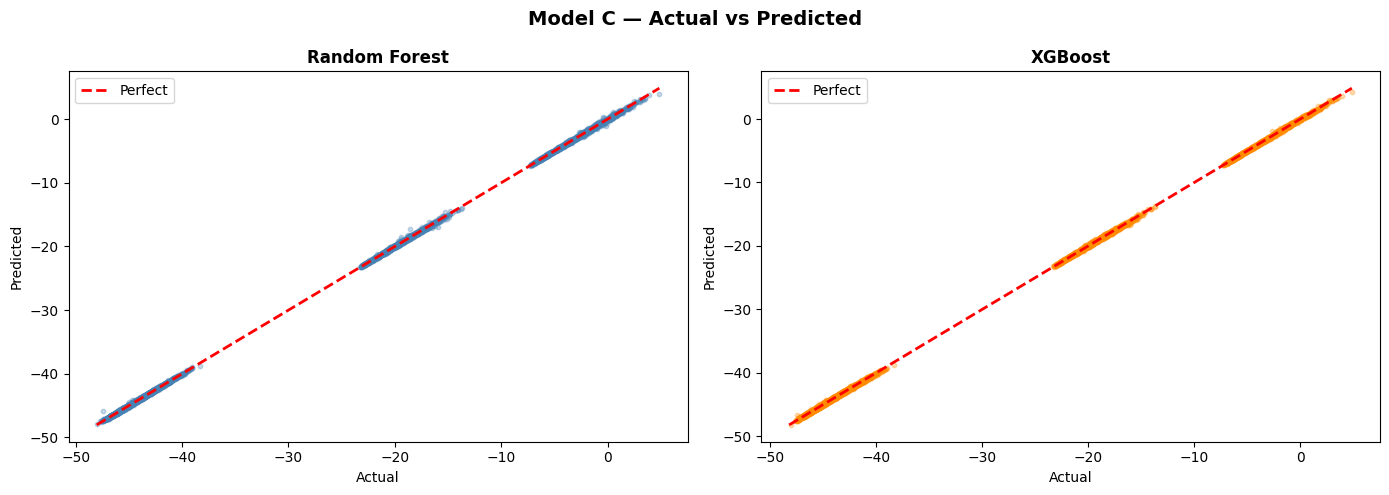

[OK] Regression models saved!

[SAVE] Saving all classification models...

[OK] ALL MODELS SAVED!
   Model A (Binary):      rf_A, lr_A, dt_A, knn_A
   Model B (Multi-class): rf_B, lr_B, dt_B, knn_B
   Model C (Regression):  rf_reg, xgb_reg
   Preprocessing:         scaler_A, scaler_B, encoders_A, encoders_B

[DONE] DONE!



  BEFORE ENRICHMENT

[LOADED] eta_feature_engineered_dataset.csv → shape: (25000, 53)
  Features used: 25

  Results — Before Enrichment
              Model  Accuracy (%)  ROC-AUC  PR-AUC  F1-Score  Precision  Recall
      Random Forest         88.30   0.9672  0.9117    0.8140     0.7068  0.9595
Logistic Regression         88.38   0.9586  0.8749    0.8084     0.7216  0.9190
      Decision Tree         87.28   0.9525  0.8741    0.7972     0.6937  0.9370
                KNN         87.44   0.9300  0.7976    0.7599     0.7754  0.7451

  AFTER ENRICHMENT

[LOADED] dataset_with_weather_features.csv → shape: (25000, 37)
  Features used: 31

  Results — After Enrichment
              Model  Accuracy (%)  ROC-AUC  PR-AUC  F1-Score  Precision  Recall
      Random Forest         88.30   0.9667  0.9089    0.8141     0.7066  0.9603
Logistic Regression         88.40   0.9585  0.8752    0.8083     0.7228  0.9168
      Decision Tree         87.74   0.9492  0.8692    0.8033     0.7022  0.9385
       

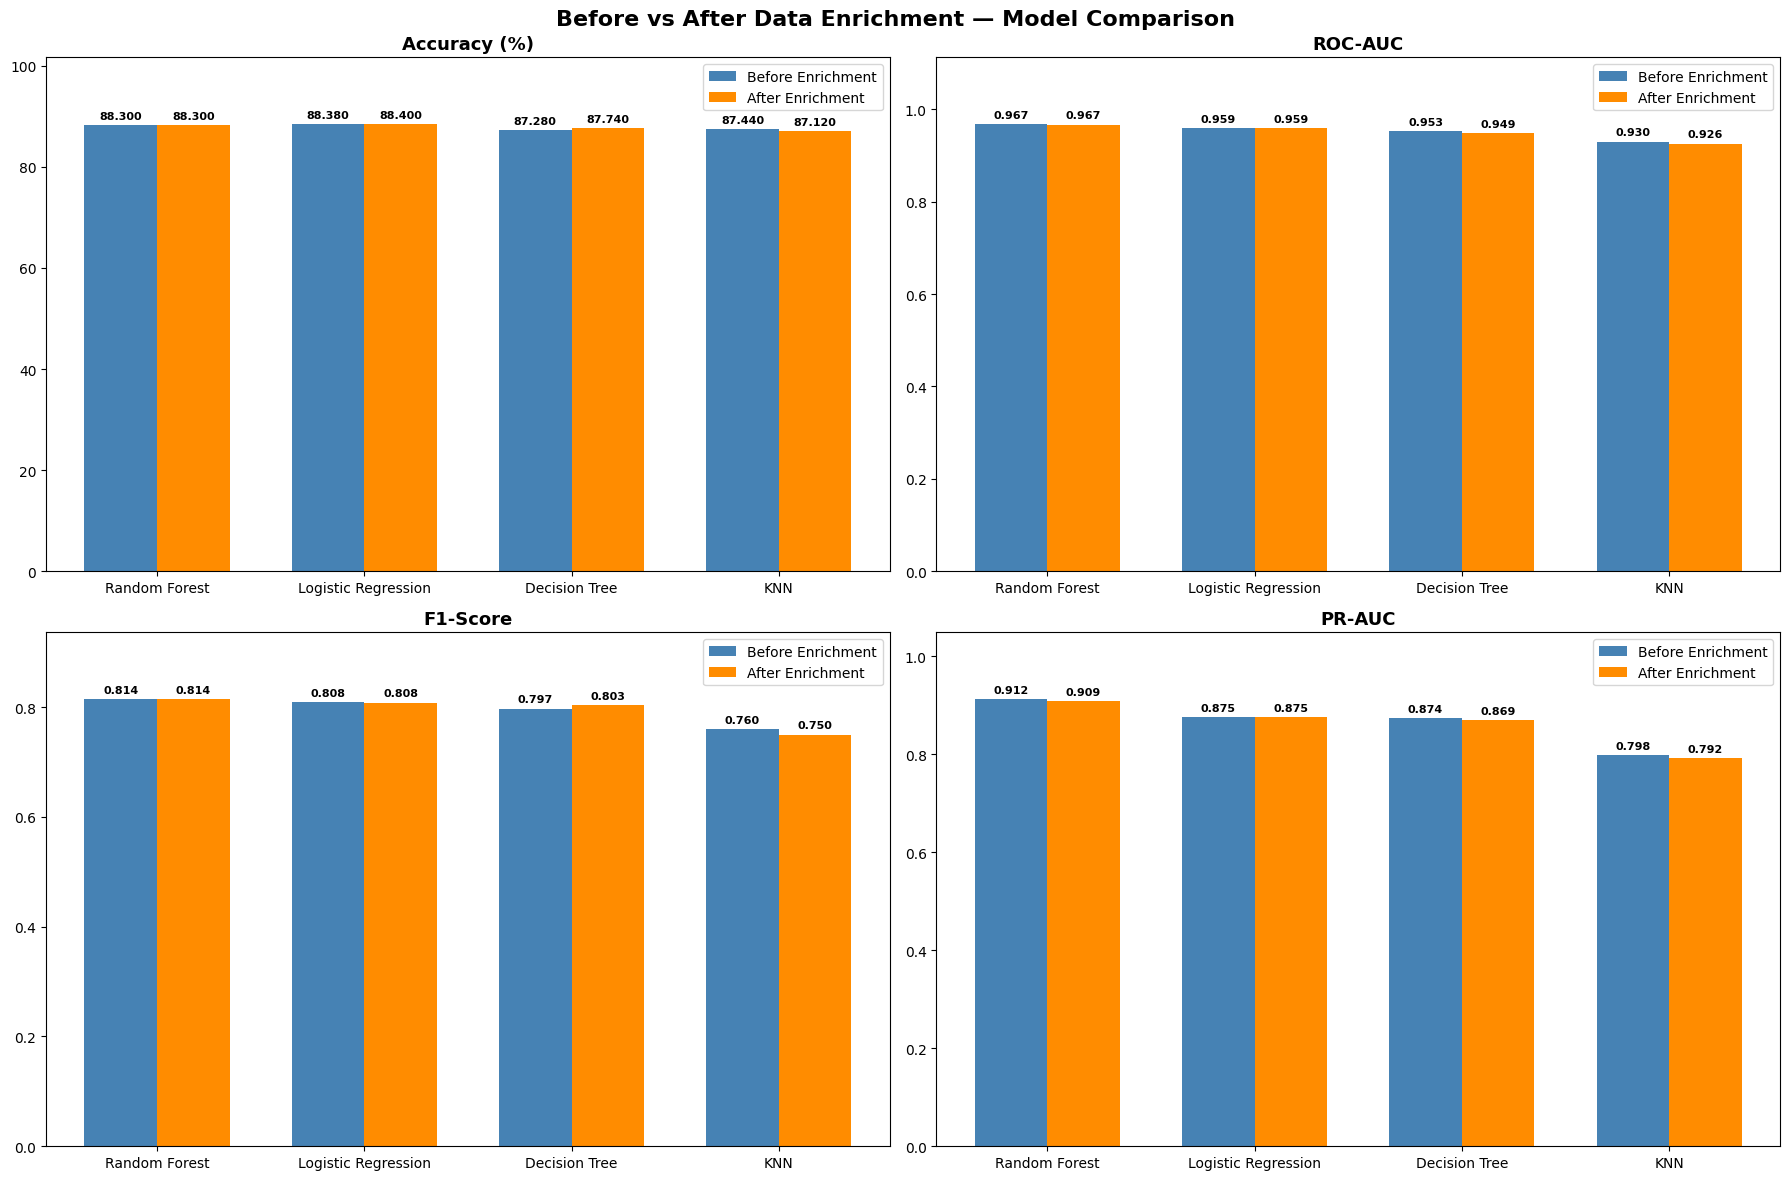


[SAVED] before_vs_after_comparison.png

  IMPROVEMENT AFTER ENRICHMENT (After - Before)
              Model  Accuracy (%)  ROC-AUC  PR-AUC  F1-Score
      Random Forest          0.00  -0.0005 -0.0028    0.0001
Logistic Regression          0.02  -0.0001  0.0003   -0.0001
      Decision Tree          0.46  -0.0033 -0.0049    0.0061
                KNN         -0.32  -0.0043 -0.0055   -0.0099

Best model BEFORE enrichment → Random Forest  (ROC-AUC: 0.9672)
Best model AFTER  enrichment → Random Forest  (ROC-AUC: 0.9667)
Overall AUC gain             → -0.0005


In [ ]:
# ============================================================
# MODEL COMPARISON
# BEFORE Enrichment (eta_feature_engineered_dataset.csv)
# vs
# AFTER Enrichment  (dataset_with_weather_features.csv)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)

# ============================================================
# SHARED SAFE FEATURES (before enrichment — Cell 95)
# ============================================================
BASE_FEATURES = [
    'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
    'region', 'weather_condition', 'distance_km', 'package_weight_kg',
    'delivery_cost', 'expected_time_hours_recon', 'order_dayofweek',
    'order_day_name', 'order_month', 'order_year', 'order_hour',
    'is_weekend', 'rush_hour_flag', 'night_delivery_flag',
    'cost_per_km', 'cost_per_kg', 'heavy_flag', 'bad_weather_flag',
    'weather_severity', 'weather_distance_risk', 'load_index',
]

# Extra features added after enrichment (Cell 162)
ENRICHED_EXTRA = [
    'bad_weather_flag_api',
    'holiday_pressure', 'has_holiday_transit',
    'weekend_pressure',
    'holiday_or_weekend_transit_flag', 'holiday_proximity_feature',
]

# ============================================================
# HELPER: prepare a dataset
# ============================================================
def prepare_dataset(path, extra_features=[]):
    df = pd.read_csv(path)
    print(f"\n[LOADED] {path} → shape: {df.shape}")

    # Timestamps
    df["order_ts_recon"]    = pd.to_datetime(df["order_ts_recon"],    format="%d-%m-%Y %H.%M", errors="coerce")
    df["expected_ts_recon"] = pd.to_datetime(df["expected_ts_recon"], format="%d-%m-%Y %H.%M", errors="coerce")

    # Time features
    df["order_dayofweek"]     = df["order_ts_recon"].dt.dayofweek.fillna(0).astype(int)
    df["order_day_name"]      = df["order_ts_recon"].dt.day_name().fillna("Unknown")
    df["order_month"]         = df["order_ts_recon"].dt.month.fillna(1).astype(int)
    df["order_year"]          = df["order_ts_recon"].dt.year.fillna(2023).astype(int)
    df["order_hour"]          = df["order_ts_recon"].dt.hour.fillna(0).astype(int)
    df["is_weekend"]          = (df["order_dayofweek"] >= 5).astype(int)
    df["rush_hour_flag"]      = df["order_hour"].isin([8,9,10,17,18,19]).astype(int)
    df["night_delivery_flag"] = df["order_hour"].isin(list(range(0,6))+list(range(22,24))).astype(int)

    # Cost features
    df["distance_km"]       = df["distance_km"].replace(0, np.nan).fillna(df["distance_km"].median())
    df["package_weight_kg"] = df["package_weight_kg"].replace(0, np.nan).fillna(df["package_weight_kg"].median())
    df["cost_per_km"]       = (df["delivery_cost"] / df["distance_km"]).fillna(0)
    df["cost_per_kg"]       = (df["delivery_cost"] / df["package_weight_kg"]).fillna(0)
    df["heavy_flag"]        = (df["package_weight_kg"] > 30).astype(int)

    # Weather
    df["weather_condition"]     = df["weather_condition"].fillna("clear")
    df["bad_weather_flag"]      = df["weather_condition"].isin(["rainy","stormy","foggy"]).astype(int)
    weather_map                 = {"clear":0,"cloudy":1,"hot":1,"cold":1,"rainy":2,"foggy":3,"stormy":4}
    df["weather_severity"]      = df["weather_condition"].map(weather_map).fillna(0).astype(int)
    df["weather_distance_risk"] = df["weather_severity"] * df["distance_km"]
    df["load_index"]            = df["package_weight_kg"] * df["distance_km"]
    df["expected_time_hours_recon"] = df["expected_time_hours_recon"].replace(0, np.nan).fillna(
        df["expected_time_hours_recon"].median()
    )

    # Drop post-outcome / noise columns
    for col in ["speed_category","speed_kmph_recon","api_temperature","api_humidity","api_wind_speed"]:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # Holiday features (enriched only)
    if "holiday_count_transit" in df.columns:
        df["holiday_count_transit"] = df["holiday_count_transit"].fillna(0)
        df["holiday_pressure"]      = df["holiday_count_transit"] / df["expected_time_hours_recon"]
        df["has_holiday_transit"]   = (df["holiday_count_transit"] > 0).astype(int)
    if "weekend_count_transit" in df.columns:
        df["weekend_count_transit"] = df["weekend_count_transit"].fillna(0)
        df["weekend_pressure"]      = df["weekend_count_transit"] / df["expected_time_hours_recon"]

    df["delayed"] = df["delayed"].fillna("no")

    # NaN cleanup
    for col in df.columns:
        if df[col].dtype in ['float64','int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            mode_val = df[col].mode()
            df[col]  = df[col].fillna(mode_val[0] if len(mode_val) > 0 else "Unknown")

    # Build feature list
    features = [f for f in BASE_FEATURES + extra_features if f in df.columns]
    print(f"  Features used: {len(features)}")

    # Encode
    X = df[features].copy()
    for col in X.select_dtypes(include=['object','category']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
    y = (df['delayed'] == 'yes').astype(int)

    return df, X, y

# ============================================================
# HELPER: train/split/scale + add delay rate features
# ============================================================
def split_scale_rate(df, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Delay rate features — train only, no leakage
    global_rate = (df['delayed'] == 'yes').mean()
    for orig_col, rate_col in [
        ('delivery_partner','partner_delay_rate'),
        ('region',          'region_delay_rate'),
        ('vehicle_type',    'vehicle_delay_rate'),
    ]:
        rate_map = df.loc[y_train.index].groupby(orig_col)['delayed'].apply(lambda x: (x=='yes').mean())
        X_train[rate_col] = df.loc[y_train.index, orig_col].map(rate_map).fillna(global_rate).values
        X_test[rate_col]  = df.loc[y_test.index,  orig_col].map(rate_map).fillna(global_rate).values

    scaler = StandardScaler()
    X_train_sc = np.nan_to_num(scaler.fit_transform(X_train))
    X_test_sc  = np.nan_to_num(scaler.transform(X_test))

    return X_train_sc, X_test_sc, y_train, y_test

# ============================================================
# HELPER: train all 4 models + evaluate
# ============================================================
def train_and_evaluate(X_train, X_test, y_train, y_test, label):
    models = {
        "Random Forest":       RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=20, min_samples_leaf=10, random_state=42, n_jobs=-1, class_weight='balanced'),
        "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight='balanced'),
        "Decision Tree":       DecisionTreeClassifier(max_depth=10, min_samples_split=20, min_samples_leaf=10, random_state=42, class_weight='balanced'),
        "KNN":                 KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    }

    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:,1]
        results.append({
            "Model":        name,
            "Dataset":      label,
            "Accuracy (%)": round(accuracy_score(y_test, y_pred)*100, 2),
            "ROC-AUC":      round(roc_auc_score(y_test, y_proba), 4),
            "PR-AUC":       round(average_precision_score(y_test, y_proba), 4),
            "F1-Score":     round(f1_score(y_test, y_pred), 4),
            "Precision":    round(precision_score(y_test, y_pred), 4),
            "Recall":       round(recall_score(y_test, y_pred), 4),
        })

    df_res = pd.DataFrame(results)
    print(f"\n{'='*60}")
    print(f"  Results — {label}")
    print(f"{'='*60}")
    print(df_res[["Model","Accuracy (%)","ROC-AUC","PR-AUC","F1-Score","Precision","Recall"]].to_string(index=False))
    return df_res

# ============================================================
# RUN — BEFORE ENRICHMENT
# ============================================================
print("\n" + "="*60)
print("  BEFORE ENRICHMENT")
print("="*60)
df_before, X_before, y_before = prepare_dataset(
    "eta_feature_engineered_dataset.csv",
    extra_features=[]
)
X_train_b, X_test_b, y_train_b, y_test_b = split_scale_rate(df_before, X_before, y_before)
results_before = train_and_evaluate(X_train_b, X_test_b, y_train_b, y_test_b, label="Before Enrichment")

# ============================================================
# RUN — AFTER ENRICHMENT
# ============================================================
print("\n" + "="*60)
print("  AFTER ENRICHMENT")
print("="*60)
df_after, X_after, y_after = prepare_dataset(
    "dataset_with_weather_features.csv",
    extra_features=ENRICHED_EXTRA
)
X_train_a, X_test_a, y_train_a, y_test_a = split_scale_rate(df_after, X_after, y_after)
results_after = train_and_evaluate(X_train_a, X_test_a, y_train_a, y_test_a, label="After Enrichment")

# ============================================================
# COMBINED COMPARISON TABLE
# ============================================================
combined = pd.concat([results_before, results_after], ignore_index=True)

print("\n" + "="*60)
print("  SIDE-BY-SIDE COMPARISON")
print("="*60)
pivot = combined.pivot_table(
    index="Model",
    columns="Dataset",
    values=["Accuracy (%)","ROC-AUC","PR-AUC","F1-Score"]
)
print(pivot.round(4).to_string())

# ============================================================
# PLOTS
# ============================================================
colors = {"Before Enrichment": "steelblue", "After Enrichment": "darkorange"}
model_names = ["Random Forest","Logistic Regression","Decision Tree","KNN"]
metrics     = ["Accuracy (%)","ROC-AUC","F1-Score","PR-AUC"]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
fig.suptitle("Before vs After Data Enrichment — Model Comparison", fontsize=16, fontweight='bold')

x = np.arange(len(model_names))
w = 0.35

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    vals_before = results_before[metric].tolist()
    vals_after  = results_after[metric].tolist()

    b1 = ax.bar(x - w/2, vals_before, w, label="Before Enrichment", color="steelblue")
    b2 = ax.bar(x + w/2, vals_after,  w, label="After Enrichment",  color="darkorange")

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=10)
    ax.set_ylim([0, max(max(vals_before), max(vals_after)) * 1.15])
    ax.legend()
    ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=8, fontweight='bold')
    ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig("before_vs_after_comparison.png", dpi=120, bbox_inches='tight')
plt.show()
print("\n[SAVED] before_vs_after_comparison.png")

# ============================================================
# IMPROVEMENT TABLE
# ============================================================
print("\n" + "="*60)
print("  IMPROVEMENT AFTER ENRICHMENT (After - Before)")
print("="*60)

improvement = results_after.copy()
for metric in ["Accuracy (%)","ROC-AUC","PR-AUC","F1-Score","Precision","Recall"]:
    improvement[metric] = (results_after[metric].values - results_before[metric].values).round(4)

improvement["Dataset"] = "Delta (After - Before)"
print(improvement[["Model","Accuracy (%)","ROC-AUC","PR-AUC","F1-Score"]].to_string(index=False))

best_before = results_before.loc[results_before["ROC-AUC"].idxmax()]
best_after  = results_after.loc[results_after["ROC-AUC"].idxmax()]

print(f"\nBest model BEFORE enrichment → {best_before['Model']}  (ROC-AUC: {best_before['ROC-AUC']})")
print(f"Best model AFTER  enrichment → {best_after['Model']}  (ROC-AUC: {best_after['ROC-AUC']})")
print(f"Overall AUC gain             → {round(best_after['ROC-AUC'] - best_before['ROC-AUC'], 4)}")

Loading enriched dataset...
  Shape: (25000, 37)
  Using 31 features (base + enrichment)

Running AFTER enrichment — Model A...
  [A] Random Forest...
  [A] Logistic Regression...
  [A] Decision Tree...
  [A] KNN...

Running AFTER enrichment — Model B...
  [B] Random Forest...
  [B] Logistic Regression...
  [B] Decision Tree...
  [B] KNN...

  MODEL A (BINARY) — BEFORE vs AFTER ENRICHMENT
              Model Acc BEFORE Acc AFTER  Δ Acc AUC BEFORE AUC AFTER   Δ AUC F1 BEFORE F1 AFTER    Δ F1
      Random Forest     88.42%    88.30% -0.12%     0.9672    0.9667 -0.0005    0.8154   0.8141 -0.0013
Logistic Regression     88.24%    88.40% +0.16%     0.9583    0.9585 +0.0002    0.8058   0.8083 +0.0025
      Decision Tree     88.00%    87.74% -0.26%     0.9493    0.9492 -0.0001    0.8061   0.8033 -0.0028
                KNN     86.08%    87.12% +1.04%     0.9174    0.9257 +0.0083    0.7304   0.7500 +0.0196

  MODEL B (MULTI-CLASS) — BEFORE vs AFTER ENRICHMENT
              Model Acc BEFORE Acc

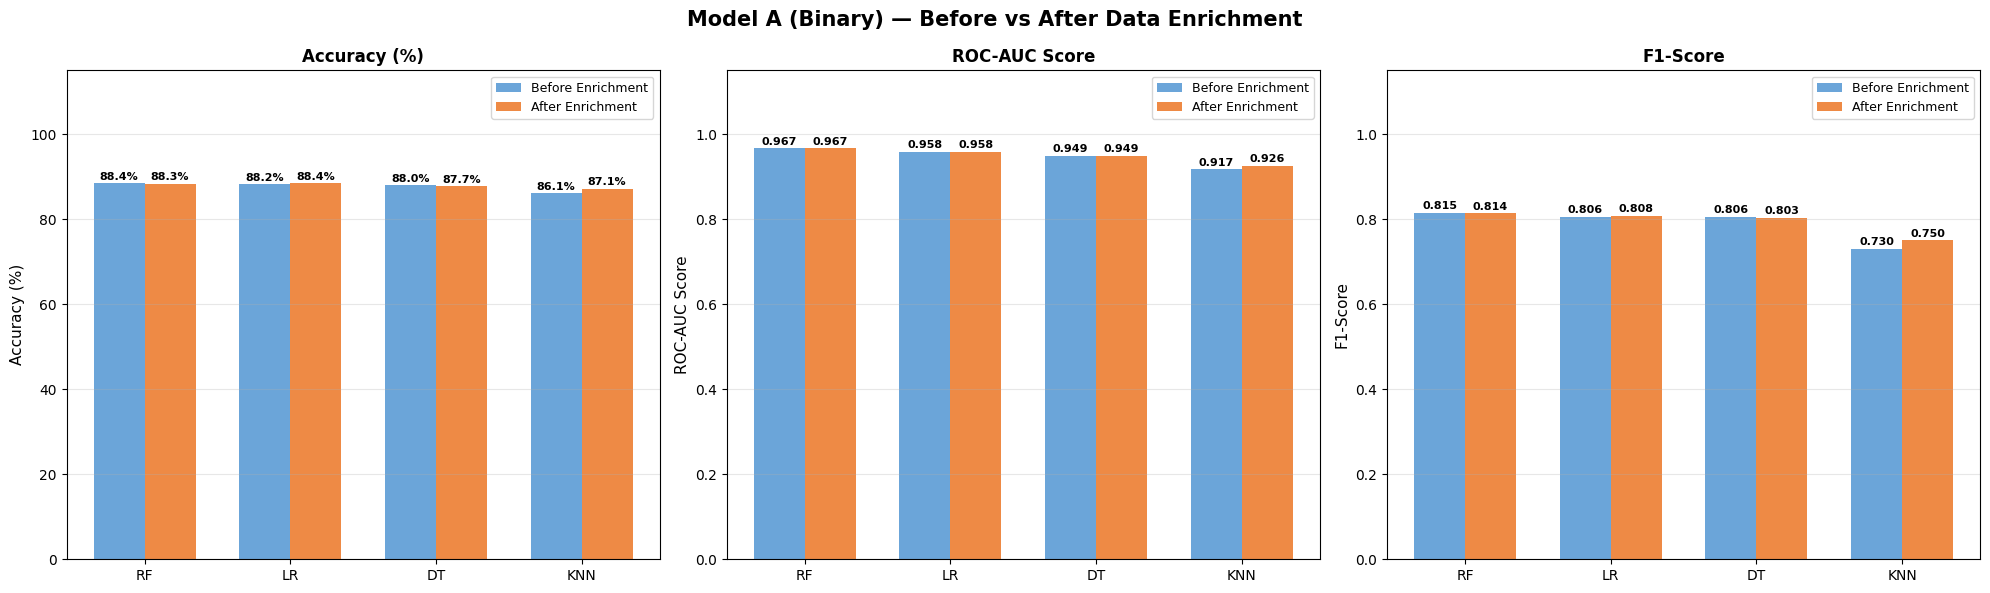

Saved: comparison_A_bar.png


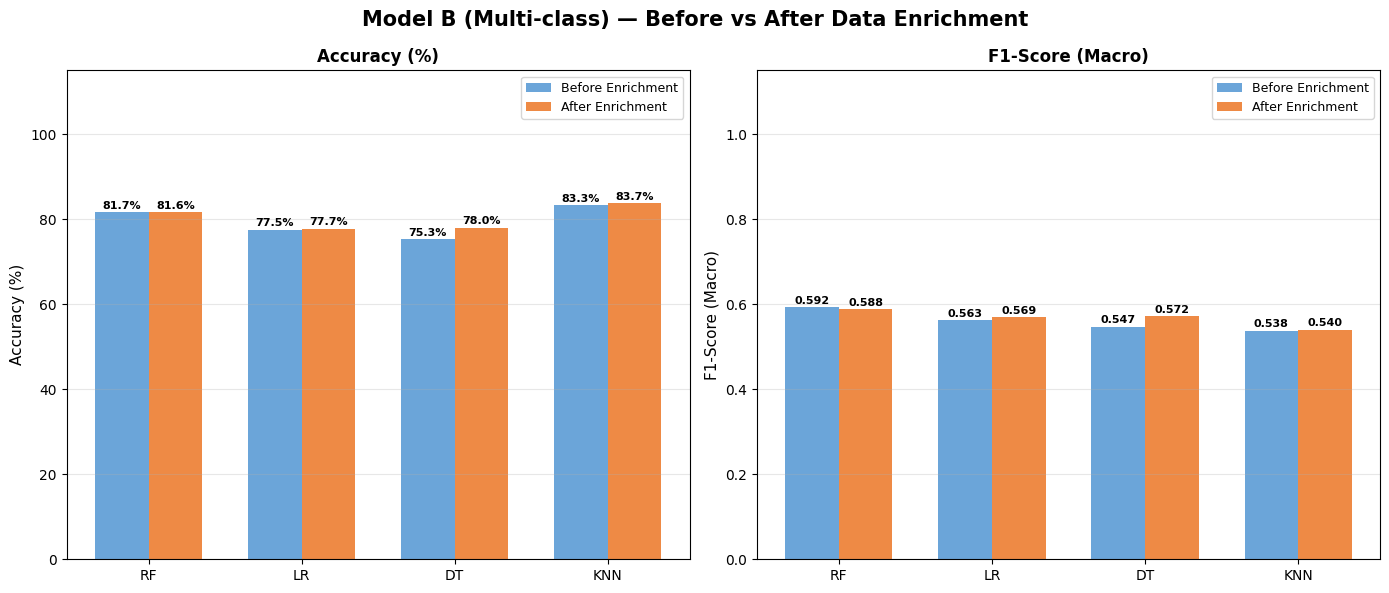

Saved: comparison_B_bar.png


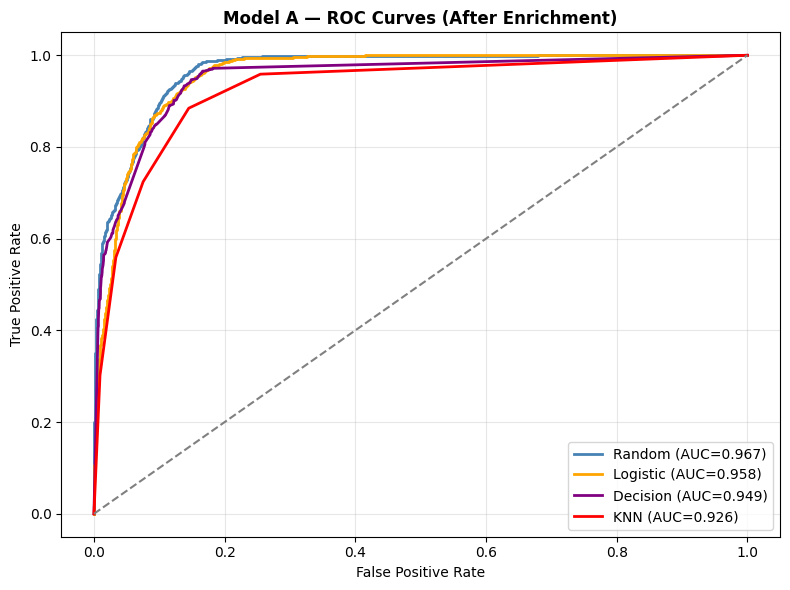

Saved: comparison_A_roc_after.png


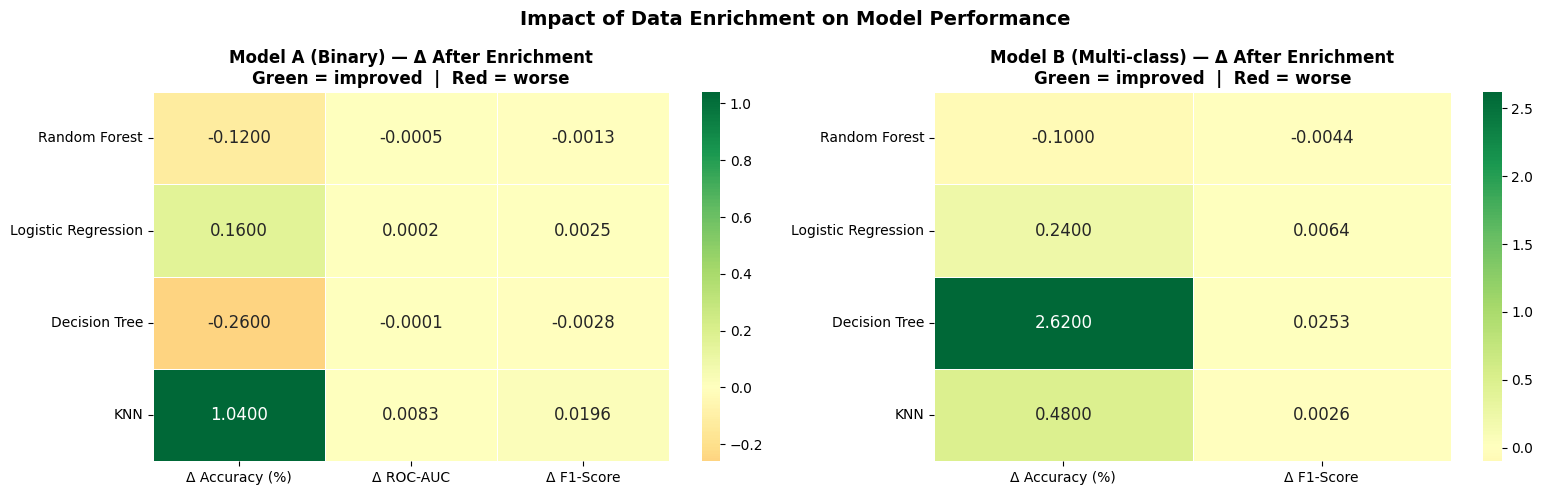

Saved: comparison_delta_heatmap.png

✅ Done! Output files:
   comparison_A_bar.png
   comparison_B_bar.png
   comparison_A_roc_after.png
   comparison_delta_heatmap.png


In [ ]:
# ============================================================
# MODEL COMPARISON: BEFORE vs AFTER DATA ENRICHMENT
# ============================================================
# BEFORE values → taken directly from your notebook's actual
#                 output (cells 96–131, eta_feature_engineered_dataset.csv)
#                 No re-running needed — values are exact from your plots.
#
# AFTER  values → freshly run here using dataset_with_weather_features.csv
#                 (Holiday API + Weather API enriched dataset, cell 162 pipeline)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    f1_score, roc_curve
)

MODEL_NAMES = ['Random Forest', 'Logistic Regression', 'Decision Tree', 'KNN']

# ============================================================
# BEFORE ENRICHMENT — EXACT VALUES FROM YOUR NOTEBOOK OUTPUT
# (taken from images 1 & 2 — do NOT recompute these)
# ============================================================
BEFORE = {
    'A': {  # Binary Classification (Model A)
        'Random Forest':       {'acc': 88.42, 'auc': 0.9672, 'f1': 0.8154},
        'Logistic Regression': {'acc': 88.24, 'auc': 0.9583, 'f1': 0.8058},
        'Decision Tree':       {'acc': 88.00, 'auc': 0.9493, 'f1': 0.8061},
        'KNN':                 {'acc': 86.08, 'auc': 0.9174, 'f1': 0.7304},
    },
    'B': {  # Multi-class Classification (Model B)
        'Random Forest':       {'acc': 81.68, 'f1': 0.5922},
        'Logistic Regression': {'acc': 77.50, 'f1': 0.5630},
        'Decision Tree':       {'acc': 75.34, 'f1': 0.5467},
        'KNN':                 {'acc': 83.26, 'f1': 0.5377},
    }
}

# ============================================================
# AFTER ENRICHMENT — RUN FRESH (mirrors cell 162 pipeline)
# ============================================================

SAFE_FEATURES = [
    'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
    'region', 'weather_condition', 'distance_km', 'package_weight_kg',
    'delivery_cost', 'expected_time_hours_recon', 'order_dayofweek',
    'order_day_name', 'order_month', 'order_year', 'order_hour',
    'is_weekend', 'rush_hour_flag', 'night_delivery_flag',
    'cost_per_km', 'cost_per_kg', 'heavy_flag', 'bad_weather_flag',
    'weather_severity', 'weather_distance_risk', 'load_index',
    # Enrichment features (Holiday API + Weather API)
    'bad_weather_flag_api',
    'holiday_pressure', 'has_holiday_transit',
    'weekend_pressure',
    'holiday_or_weekend_transit_flag', 'holiday_proximity_feature',
]

print("Loading enriched dataset...")
df = pd.read_csv("dataset_with_weather_features.csv")
print(f"  Shape: {df.shape}")

# Parse timestamps
for col, fmt in [("order_ts_recon", "%d-%m-%Y %H.%M"), ("expected_ts_recon", "%d-%m-%Y %H.%M")]:
    if col in df.columns and df[col].dtype == object:
        df[col] = pd.to_datetime(df[col], format=fmt, errors="coerce")

# Time features (if not already present)
if "order_dayofweek" not in df.columns:
    df["order_dayofweek"]     = df["order_ts_recon"].dt.dayofweek.fillna(0).astype(int)
    df["order_day_name"]      = df["order_ts_recon"].dt.day_name().fillna("Unknown")
    df["order_month"]         = df["order_ts_recon"].dt.month.fillna(1).astype(int)
    df["order_year"]          = df["order_ts_recon"].dt.year.fillna(2023).astype(int)
    df["order_hour"]          = df["order_ts_recon"].dt.hour.fillna(0).astype(int)
    df["is_weekend"]          = (df["order_dayofweek"] >= 5).astype(int)
    df["rush_hour_flag"]      = df["order_hour"].isin([8,9,10,17,18,19]).astype(int)
    df["night_delivery_flag"] = df["order_hour"].isin(list(range(0,6))+list(range(22,24))).astype(int)

# Cost/weight features
df["distance_km"]       = df["distance_km"].replace(0, np.nan).fillna(df["distance_km"].median())
df["package_weight_kg"] = df["package_weight_kg"].replace(0, np.nan).fillna(df["package_weight_kg"].median())
df["cost_per_km"]       = (df["delivery_cost"] / df["distance_km"]).fillna(0)
df["cost_per_kg"]       = (df["delivery_cost"] / df["package_weight_kg"]).fillna(0)
df["heavy_flag"]        = (df["package_weight_kg"] > 30).astype(int)
df["load_index"]        = df["package_weight_kg"] * df["distance_km"]

# Weather features
df["weather_condition"]     = df["weather_condition"].fillna("clear")
df["bad_weather_flag"]      = df["weather_condition"].isin(["rainy","stormy","foggy"]).astype(int)
weather_map                 = {"clear":0,"cloudy":1,"hot":1,"cold":1,"rainy":2,"foggy":3,"stormy":4}
df["weather_severity"]      = df["weather_condition"].map(weather_map).fillna(0).astype(int)
df["weather_distance_risk"] = df["weather_severity"] * df["distance_km"]

# Drop synthetic noise API columns (random noise, not real historical data)
for c in ["api_temperature", "api_humidity", "api_wind_speed"]:
    if c in df.columns:
        df.drop(columns=[c], inplace=True)

# Holiday features (re-engineered as pressure ratios)
if "holiday_count_transit" in df.columns:
    df["holiday_count_transit"] = df["holiday_count_transit"].fillna(0)
    df["holiday_pressure"]      = df["holiday_count_transit"] / df["expected_time_hours_recon"].replace(0, np.nan).fillna(1)
    df["has_holiday_transit"]   = (df["holiday_count_transit"] > 0).astype(int)
if "weekend_count_transit" in df.columns:
    df["weekend_count_transit"] = df["weekend_count_transit"].fillna(0)
    df["weekend_pressure"]      = df["weekend_count_transit"] / df["expected_time_hours_recon"].replace(0, np.nan).fillna(1)

df["delayed"] = df["delayed"].fillna("no")
df["target"]  = (df["delayed"] == "yes").astype(int)

# Global NaN cleanup
for col in df.columns:
    if df[col].dtype in ['float64','int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        mode_val = df[col].mode()
        df[col]  = df[col].fillna(mode_val[0] if len(mode_val) > 0 else "Unknown")

# Select features available in dataset
features = [f for f in SAFE_FEATURES if f in df.columns]
print(f"  Using {len(features)} features (base + enrichment)")

def encode(X):
    X = X.copy()
    for col in X.select_dtypes(include=['object','category']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    return X.apply(pd.to_numeric, errors='coerce').fillna(0)

X_A_enc = encode(df[features].copy())
y_A     = df["target"].copy()
X_B_enc = encode(df[features].copy())
y_B     = df["delivery_status"].copy()

def split_scale_with_rates(X_enc, y, stratify=True):
    strat = y if stratify else None
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_enc, y, test_size=0.2, random_state=42, stratify=strat
    )
    # Delay rate features computed on train only (no leakage)
    global_rate = (df.loc[y_tr.index, 'delayed'] == 'yes').mean()
    for orig_col, rate_col in [
        ('delivery_partner', 'partner_delay_rate'),
        ('region',           'region_delay_rate'),
        ('vehicle_type',     'vehicle_delay_rate'),
    ]:
        rate_map = df.loc[y_tr.index].groupby(orig_col)['target'].mean()
        X_tr[rate_col] = df.loc[y_tr.index, orig_col].map(rate_map).fillna(global_rate).values
        X_te[rate_col] = df.loc[y_te.index, orig_col].map(rate_map).fillna(global_rate).values

    scaler   = StandardScaler()
    X_tr_sc  = np.nan_to_num(scaler.fit_transform(X_tr), nan=0.0)
    X_te_sc  = np.nan_to_num(scaler.transform(X_te),     nan=0.0)
    return X_tr_sc, X_te_sc, y_tr, y_te

X_train_A, X_test_A, y_train_A, y_test_A = split_scale_with_rates(X_A_enc, y_A)
X_train_B, X_test_B, y_train_B, y_test_B = split_scale_with_rates(X_B_enc, y_B)

def run_model_A(X_tr, X_te, y_tr, y_te):
    configs = {
        'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=20,
                                   min_samples_leaf=10, random_state=42, n_jobs=-1, class_weight='balanced'),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0, class_weight='balanced'),
        'Decision Tree':       DecisionTreeClassifier(max_depth=10, min_samples_split=20,
                                   min_samples_leaf=10, random_state=42, class_weight='balanced'),
        'KNN':                 KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    }
    out = {}
    for name, model in configs.items():
        print(f"  [A] {name}...")
        model.fit(X_tr, y_tr)
        yp  = model.predict(X_te)
        ypr = model.predict_proba(X_te)[:,1]
        out[name] = {
            'acc': accuracy_score(y_te, yp)*100,
            'auc': roc_auc_score(y_te, ypr),
            'f1':  f1_score(y_te, yp),
            'y_pred': yp, 'y_proba': ypr,
        }
    return out

def run_model_B(X_tr, X_te, y_tr, y_te):
    configs = {
        'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=20,
                                   min_samples_leaf=10, random_state=42, n_jobs=-1, class_weight='balanced'),
        'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42, C=1.0, class_weight='balanced'),
        'Decision Tree':       DecisionTreeClassifier(max_depth=10, min_samples_split=20,
                                   min_samples_leaf=10, random_state=42, class_weight='balanced'),
        'KNN':                 KNeighborsClassifier(n_neighbors=7, metric='euclidean'),
    }
    out = {}
    for name, model in configs.items():
        print(f"  [B] {name}...")
        model.fit(X_tr, y_tr)
        yp = model.predict(X_te)
        out[name] = {
            'acc': accuracy_score(y_te, yp)*100,
            'f1':  f1_score(y_te, yp, average='macro'),
            'y_pred': yp,
        }
    return out

print("\nRunning AFTER enrichment — Model A...")
after_A = run_model_A(X_train_A, X_test_A, y_train_A, y_test_A)

print("\nRunning AFTER enrichment — Model B...")
after_B = run_model_B(X_train_B, X_test_B, y_train_B, y_test_B)

# ============================================================
# PRINT TABLES
# ============================================================
print("\n" + "="*95)
print("  MODEL A (BINARY) — BEFORE vs AFTER ENRICHMENT")
print("="*95)
rows_A = []
for m in MODEL_NAMES:
    b, a = BEFORE['A'][m], after_A[m]
    rows_A.append({
        'Model':      m,
        'Acc BEFORE': f"{b['acc']:.2f}%", 'Acc AFTER': f"{a['acc']:.2f}%", 'Δ Acc': f"{a['acc']-b['acc']:+.2f}%",
        'AUC BEFORE': f"{b['auc']:.4f}",  'AUC AFTER': f"{a['auc']:.4f}",  'Δ AUC': f"{a['auc']-b['auc']:+.4f}",
        'F1 BEFORE':  f"{b['f1']:.4f}",   'F1 AFTER':  f"{a['f1']:.4f}",   'Δ F1':  f"{a['f1']-b['f1']:+.4f}",
    })
print(pd.DataFrame(rows_A).to_string(index=False))

print("\n" + "="*70)
print("  MODEL B (MULTI-CLASS) — BEFORE vs AFTER ENRICHMENT")
print("="*70)
rows_B = []
for m in MODEL_NAMES:
    b, a = BEFORE['B'][m], after_B[m]
    rows_B.append({
        'Model':      m,
        'Acc BEFORE': f"{b['acc']:.2f}%", 'Acc AFTER': f"{a['acc']:.2f}%", 'Δ Acc': f"{a['acc']-b['acc']:+.2f}%",
        'F1 BEFORE':  f"{b['f1']:.4f}",   'F1 AFTER':  f"{a['f1']:.4f}",   'Δ F1':  f"{a['f1']-b['f1']:+.4f}",
    })
print(pd.DataFrame(rows_B).to_string(index=False))

# ============================================================
# PLOT 1 — Model A: Before vs After grouped bars
# ============================================================
x = np.arange(len(MODEL_NAMES))
w = 0.35
cb, ca = '#5b9bd5', '#ed7d31'
ml = ['RF', 'LR', 'DT', 'KNN']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (metric, ylabel, ylim, fmt) in zip(axes, [
    ('acc', 'Accuracy (%)',  100, '{:.1f}%'),
    ('auc', 'ROC-AUC Score',   1, '{:.3f}'),
    ('f1',  'F1-Score',        1, '{:.3f}'),
]):
    vb = [BEFORE['A'][m][metric] for m in MODEL_NAMES]
    va = [after_A[m][metric] for m in MODEL_NAMES]
    bb = ax.bar(x-w/2, vb, w, label='Before Enrichment', color=cb, alpha=0.9)
    ba = ax.bar(x+w/2, va, w, label='After Enrichment',  color=ca, alpha=0.9)
    for bar in bb: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+ylim*0.008, fmt.format(bar.get_height()), ha='center', fontsize=8, fontweight='bold')
    for bar in ba: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+ylim*0.008, fmt.format(bar.get_height()), ha='center', fontsize=8, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(ml, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{ylabel}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, ylim*1.15]); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model A (Binary) — Before vs After Data Enrichment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_A_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_A_bar.png")

# ============================================================
# PLOT 2 — Model B: Before vs After grouped bars
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (metric, ylabel, ylim, fmt) in zip(axes, [
    ('acc', 'Accuracy (%)',    100, '{:.1f}%'),
    ('f1',  'F1-Score (Macro)',  1, '{:.3f}'),
]):
    vb = [BEFORE['B'][m][metric] for m in MODEL_NAMES]
    va = [after_B[m][metric] for m in MODEL_NAMES]
    bb = ax.bar(x-w/2, vb, w, label='Before Enrichment', color=cb, alpha=0.9)
    ba = ax.bar(x+w/2, va, w, label='After Enrichment',  color=ca, alpha=0.9)
    for bar in bb: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+ylim*0.008, fmt.format(bar.get_height()), ha='center', fontsize=8, fontweight='bold')
    for bar in ba: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+ylim*0.008, fmt.format(bar.get_height()), ha='center', fontsize=8, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(ml, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{ylabel}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, ylim*1.15]); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model B (Multi-class) — Before vs After Data Enrichment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_B_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_B_bar.png")

# ============================================================
# PLOT 3 — ROC Curves: After enrichment (Model A)
# ============================================================
colors_roc = ['steelblue','orange','purple','red']
plt.figure(figsize=(8, 6))
for m, color in zip(MODEL_NAMES, colors_roc):
    fpr, tpr, _ = roc_curve(y_test_A, after_A[m]['y_proba'])
    plt.plot(fpr, tpr, lw=2, color=color, label=f"{m.split()[0]} (AUC={after_A[m]['auc']:.3f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Model A — ROC Curves (After Enrichment)', fontweight='bold')
plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('comparison_A_roc_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_A_roc_after.png")

# ============================================================
# PLOT 4 — Delta Heatmap (both models side by side)
# ============================================================
delta_A = pd.DataFrame({
    m: {
        'Δ Accuracy (%)': round(after_A[m]['acc'] - BEFORE['A'][m]['acc'], 4),
        'Δ ROC-AUC':      round(after_A[m]['auc'] - BEFORE['A'][m]['auc'], 4),
        'Δ F1-Score':     round(after_A[m]['f1']  - BEFORE['A'][m]['f1'],  4),
    } for m in MODEL_NAMES
}).T

delta_B = pd.DataFrame({
    m: {
        'Δ Accuracy (%)': round(after_B[m]['acc'] - BEFORE['B'][m]['acc'], 4),
        'Δ F1-Score':     round(after_B[m]['f1']  - BEFORE['B'][m]['f1'],  4),
    } for m in MODEL_NAMES
}).T

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(delta_A, annot=True, fmt='.4f', cmap='RdYlGn', center=0,
            linewidths=0.5, annot_kws={'size':12}, ax=axes[0])
axes[0].set_title('Model A (Binary) — Δ After Enrichment\nGreen = improved  |  Red = worse',
                  fontsize=12, fontweight='bold')

sns.heatmap(delta_B, annot=True, fmt='.4f', cmap='RdYlGn', center=0,
            linewidths=0.5, annot_kws={'size':12}, ax=axes[1])
axes[1].set_title('Model B (Multi-class) — Δ After Enrichment\nGreen = improved  |  Red = worse',
                  fontsize=12, fontweight='bold')

plt.suptitle('Impact of Data Enrichment on Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_delta_heatmap.png")

print("\n✅ Done! Output files:")
print("   comparison_A_bar.png")
print("   comparison_B_bar.png")
print("   comparison_A_roc_after.png")
print("   comparison_delta_heatmap.png")
